# Production Actual Backtest (2026-02-27 → now)

**Single method (`prod` only):** each archived `etf_screened_today.csv` is sized with
**today's** full `generate_trade_plan` stack (B1/B2 + B4 opt2 → crash → smooth →
ratchet), carrying isolated state forward day-to-day. Spot `borrow_current` and
screener edge/opt2 inputs match production (no avg-borrow overlay). Archived
`proposed_trades.csv` is **not** used.

```text
screened(as-of D) + state[D-1] + held shorts from plan[D-1]
  → size_book_from_screened (full GTP)
  → plan[D] + state[D]
  → scale sleeve legs to YAML budget
  → simulate_book_from_plan_timeline (next-close, W-FRI Phase-2b, costs)
```

Capital / sleeve budgets come from live `strategy_config.yml`. B3 flow is excluded.
Between Fridays the book share-holds (no daily OLS hedge rebuild). Each sleeve with
positive plan gross is scaled so sleeve gross equals the YAML sleeve budget.

**Start:** `2026-02-27` (first screened archive after the Dec→Feb gap; sparse thereafter).
B5 only when GTP sizes it; no live locates / execution rejects.

When today's GTP cannot size an old screened file, the timeline **falls back** to that
date's archived `proposed_trades.csv` (and also ingests plan-only archive dates).


In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:,.4f}".format

REPO = Path.cwd()
if not (REPO / "generate_trade_plan.py").exists():
    if (REPO.parent / "generate_trade_plan.py").exists():
        REPO = REPO.parent
sys.path.insert(0, str(REPO))

RUN_DATE = "2026-07-10"          # price panel date
START = "2026-02-27"
PRE_ARCHIVE_POLICY = "cash"      # "cash" | "skip"
FORCE_RERUN = False  # True only to rebuild CSVs; False loads cached outputs and plots
OUT_BASE = REPO / "notebooks" / "output" / "production_actual_bt"

# Embed plots in the notebook when cells execute.
%matplotlib inline

SLEEVE_LABELS = {
    "core_leveraged": "B1 core",
    "yieldboost": "B2 yieldboost",
    "inverse_decay_bucket4": "B4 inverse",
    "volatility_etp_bucket5": "B5 vol ETP",
}
SLEEVE_ORDER = list(SLEEVE_LABELS)

print("REPO", REPO)
print("RUN_DATE", RUN_DATE, "START", START, "mode=prod")


REPO C:\Users\drewg\Projects\quant\ls-algo
RUN_DATE 2026-07-10 START 2026-02-27 mode=prod


## Archive coverage


In [2]:
from scripts.production_actual_backtest import archive_coverage_summary, list_archived_plan_dates, list_archived_screened_dates

cov = archive_coverage_summary(START)
display(cov)
print("n proposed_trades dates:", len(list_archived_plan_dates()), "(unused by prod)")
print("n screened dates:", len(list_archived_screened_dates()))
print("first screened:", list_archived_screened_dates()[0].date() if list_archived_screened_dates() else None)


,artifact,n_dates,first,last,n_on_or_after_start,gap_before_first_plan_days
0,proposed_trades.csv,84,2025-12-28,2026-07-13,80,0
1,etf_screened_today.csv,52,2025-12-28,2026-07-13,50,0


n proposed_trades dates: 84 (unused by prod)
n screened dates: 52
first screened: 2025-12-28


## Production-accounting parity checklist

`Implemented` means the ledger models the behavior directly. `Proxy` is
intentionally visible in the cost and sensitivity charts. `Gap` should not be
read as production-accurate until the missing artifact is archived.


In [3]:
assumption_audit = pd.DataFrame([
    ["Gross sizing", "Dynamic NAV × target gross", "Scale sleeve legs to YAML budget, then × NAV/capital", "Implemented"],
    ["Plan source", "Live generate_trade_plan", "Full GTP sizing on archived screened (isolated state)", "Implemented"],
    ["Plan timing", "Signal known after close", "T plan executes next available close; P&L starts next session", "Implemented"],
    ["Between rebals", "Hold shares; legs drift", "Signed ETF/underlying notionals drift with each leg", "Implemented"],
    ["Leg schema", "Underlying target + ETF target", "long_usd=underlying; short_usd=ETF; explicit columns preferred", "Implemented"],
    ["Rebalance", "Phase-2b hysteresis + weekly clock", "W-FRI; 12% enter / 4% exit / $250; existing legs only", "Implemented"],
    ["Purgatory", "0-target keep-open (no new size, no auto-close)", "keep_open rows held in sim (not liquidated)", "Implemented"],
    ["Slippage", "Broker/fill dependent", "20 bp on every traded dollar, including opening trades", "Proxy"],
    ["Commission", "Clear Street low-touch", "$0.0035/share by leg", "Implemented"],
    ["Borrow", "Point-in-time by short symbol", "Screened spot borrow_current carried until the next plan", "Implemented"],
    ["Short credit", "IBKR interest on short proceeds", "3.8% annual on short notional / Actual-360", "Implemented"],
    ["Margin debit", "OBFR + 45 bp, Actual/360", "4.00% benchmark fallback + 45 bp, Actual/360", "Proxy"],
    ["Prices", "Total-return / split-safe marks", "Adjusted-close panel + Flex/override/heuristic split repair", "Implemented"],
    ["Missing bars", "Carry last mark; cannot trade", "Zero-return stale mark; blocked close/entry is audited", "Implemented"],
    ["Share rounding", "Whole shares / broker lots", "Dollar-notional targets", "Gap"],
    ["Locates", "Can reject or resize shorts", "Screened universe at sizing time; no execution reject", "Gap"],
    ["B4 stack", "opt2 → crash → smooth → ratchet", "Same stack; state isolated + ratchet from prior plan", "Implemented"],
    ["Archive window", "Full history", "Start 2026-02-27; pre-Apr-25 edge shimmed from net_decay when net_edge_p50 missing", "Implemented"],
], columns=["Item", "Production", "This backtest", "Status"])
display(assumption_audit)


,Item,Production,This backtest,Status
0,Gross sizing,Dynamic NAV × target gross,"Scale sleeve legs to YAML budget, then × NAV/c...",Implemented
1,Plan source,Live generate_trade_plan,Full GTP sizing on archived screened (isolated...,Implemented
2,Plan timing,Signal known after close,T plan executes next available close; P&L star...,Implemented
3,Between rebals,Hold shares; legs drift,Signed ETF/underlying notionals drift with eac...,Implemented
4,Leg schema,Underlying target + ETF target,long_usd=underlying; short_usd=ETF; explicit c...,Implemented
5,Rebalance,Phase-2b hysteresis + weekly clock,W-FRI; 12% enter / 4% exit / $250; existing le...,Implemented
6,Purgatory,"0-target keep-open (no new size, no auto-close)",keep_open rows held in sim (not liquidated),Implemented
7,Slippage,Broker/fill dependent,"20 bp on every traded dollar, including openin...",Proxy
8,Commission,Clear Street low-touch,$0.0035/share by leg,Implemented
9,Borrow,Point-in-time by short symbol,Screened spot borrow_current carried until the...,Implemented


## B4 crash-budget + scale-to-budget snapshot (live GTP)

`crash_budget_mult < 1` means the pair was trimmed by ρ·budget/L before the
sleeve refill. With `scale_to_budget: true`, those trims are then scaled
pro-rata so sleeve gross ≈ YAML `target_weight`.


,ETF,Underlying,weight_solved,weight_capped,weight_final,gross_solved_usd,gross_capped_usd,gross_final_usd,cap_usd,crash_budget_mult,scale_to_budget,scale_mult,L,C,runup,tail,hedge_ratio,crash_l_source
0,LITZ,LITE,0.1695,0.0143,0.0922,"19,575.0414","1,646.7390","10,647.3801","1,646.7390",0.0841,True,6.4657,0.5260,0.5670,1.1574,0.5670,0.3706,signal
1,SNDQ,SNDK,0.1304,0.0121,0.0780,"15,062.1051","1,392.5791","9,004.0491","1,392.5791",0.0925,True,6.4657,0.6220,0.7287,4.4322,0.7287,0.4245,signal
2,MSTZ,MSTR,0.1214,0.0114,0.0735,"14,022.0075","1,312.8887","8,488.7919","1,312.8887",0.0936,True,6.4657,0.6598,0.6616,0.0000,0.6616,0.3568,signal
3,CORD,CRWV,0.0948,0.0113,0.0733,"10,953.2418","1,309.6743","8,468.0084","1,309.6743",0.1196,True,6.4657,0.6614,0.7101,0.0000,0.7101,0.3892,signal
4,NBIZ,NBIS,0.0985,0.0128,0.0826,"11,375.4153","1,476.3470","9,545.6704","1,476.3470",0.1298,True,6.4657,0.5868,0.7254,1.1203,0.7254,0.4437,signal
5,QBTZ,QBTS,0.1020,0.0151,0.0974,"11,785.0968","1,739.6824","11,248.3277","1,739.6824",0.1476,True,6.4657,0.4979,0.7598,0.0000,0.7598,0.5164,signal
6,RKLZ,RKLB,0.0989,0.0189,0.1223,"11,425.7503","2,183.9534","14,120.8668","2,183.9534",0.1911,True,6.4657,0.3966,0.6979,0.2194,0.6979,0.5550,signal
7,CONI,COIN,0.0627,0.0132,0.0853,"7,243.3465","1,523.4640","9,850.3163","1,523.4640",0.2103,True,6.4657,0.5686,0.6288,0.0000,0.6288,0.3811,signal
8,DAMD,AMD,0.0940,0.0199,0.1286,"10,862.4838","2,296.8516","14,850.8365","2,296.8516",0.2114,True,6.4657,0.3771,0.5129,1.5373,0.5129,0.4486,signal
9,SSPC,SPCX,0.0141,0.0122,0.0791,"1,626.9130","1,412.6171","9,133.6093","1,412.6171",0.8683,True,6.4657,0.6132,NaN,NaN,NaN,0.7500,book_quantile


solved $115,500 → post-cap $17,863 → final $115,500 (scale_to_budget=True, scale_mult=6.466); n_capped=10/11


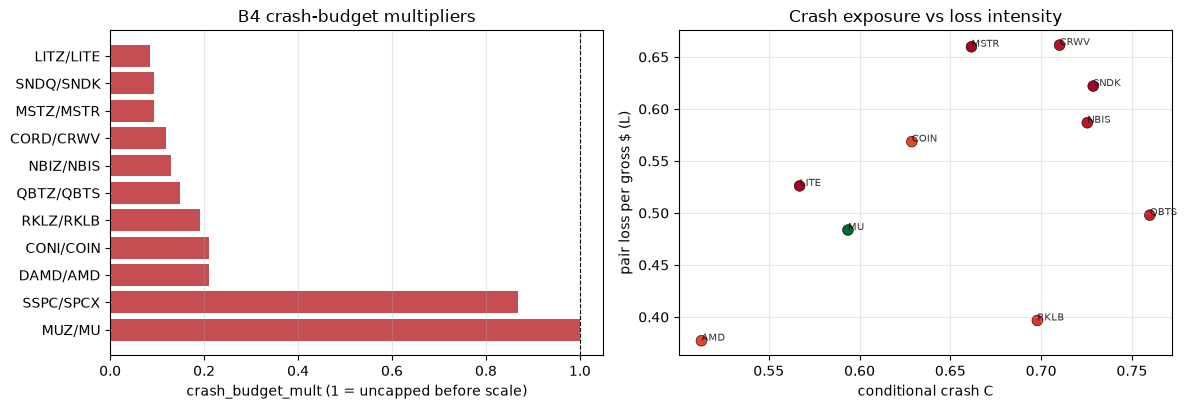

In [4]:
cb_candidates = [
    REPO / "data" / "runs" / RUN_DATE / "b4_crash_budget.csv",
    REPO / "data" / "runs" / RUN_DATE / "b4_hedge_cadence" / "b4_crash_budget.csv",
]
cb_path = next((p for p in cb_candidates if p.is_file()), cb_candidates[0])
if cb_path.is_file():
    cb = pd.read_csv(cb_path)
    cols = [c for c in [
        "ETF", "Underlying", "weight_solved", "weight_capped", "weight_final",
        "gross_solved_usd", "gross_capped_usd", "gross_final_usd", "cap_usd",
        "crash_budget_mult", "scale_to_budget", "scale_mult",
        "L", "C", "runup", "tail", "hedge_ratio", "crash_l_source",
    ] if c in cb.columns]
    display(cb[cols].sort_values("crash_budget_mult").round(4))

    solved = float(cb["gross_solved_usd"].sum()) if "gross_solved_usd" in cb.columns else np.nan
    capped = float(cb["gross_capped_usd"].sum()) if "gross_capped_usd" in cb.columns else np.nan
    final = float(cb["gross_final_usd"].sum()) if "gross_final_usd" in cb.columns else capped
    scale_mult = float(cb["scale_mult"].iloc[0]) if "scale_mult" in cb.columns and len(cb) else np.nan
    scale_on = bool(cb["scale_to_budget"].iloc[0]) if "scale_to_budget" in cb.columns and len(cb) else False
    print(
        f"solved ${solved:,.0f} → post-cap ${capped:,.0f} → final ${final:,.0f} "
        f"(scale_to_budget={scale_on}, scale_mult={scale_mult:.3f}); "
        f"n_capped={(cb['crash_budget_mult'] < 0.999).sum()}/{len(cb)}"
        if "crash_budget_mult" in cb.columns else f"rows={len(cb)}"
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    ax = axes[0]
    if {"ETF", "Underlying", "crash_budget_mult"}.issubset(cb.columns):
        top = cb.sort_values("crash_budget_mult").head(12)
        ax.barh(top["ETF"] + "/" + top["Underlying"], top["crash_budget_mult"], color="#c44e52")
        ax.axvline(1.0, color="k", lw=0.8, ls="--")
        ax.set_xlabel("crash_budget_mult (1 = uncapped before scale)")
        ax.set_title("B4 crash-budget multipliers")
        ax.invert_yaxis()
        ax.grid(True, axis="x", alpha=0.3)
    ax = axes[1]
    if {"C", "L", "crash_budget_mult", "Underlying"}.issubset(cb.columns):
        ax.scatter(cb["C"], cb["L"], c=cb["crash_budget_mult"], cmap="RdYlGn", s=60, edgecolor="k", lw=0.4)
        for _, r in cb.iterrows():
            ax.annotate(r["Underlying"], (r["C"], r["L"]), fontsize=7, alpha=0.8)
        ax.set_xlabel("conditional crash C")
        ax.set_ylabel("pair loss per gross $ (L)")
        ax.set_title("Crash exposure vs loss intensity")
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"no crash-budget telemetry at {cb_path} — re-run generate_trade_plan.py for {RUN_DATE}")


## B4 sizing waterfall (opt2 → cap/scale → smooth → legs)

`b4_sizing_waterfall.csv` is the per-pair audit of the four-step stack.


,ETF,Underlying,weight_solved,weight_capped,weight_smoothed,gross_decay_score_usd,gross_after_caps_usd,gross_after_smooth_usd,gross_final_usd,inverse_short_final_usd,underlying_short_final_usd,L,C,rho_effective,crash_l_source
0,DAMD,AMD,0.0940,0.1286,0.1286,"1,451.2316","14,850.8365","14,850.7867","14,850.7866","-7,779.0238","-7,071.7628",0.3771,0.5129,0.0485,signal
1,RKLZ,RKLB,0.0989,0.1223,0.1223,"6,159.1370","14,120.8668","14,120.8186","14,120.8185","-6,699.7558","-7,421.0627",0.3966,0.6979,0.0485,signal
2,QBTZ,QBTS,0.1020,0.0974,0.0974,"23,100.0000","11,248.3277","11,248.2897","11,248.2896","-5,543.7845","-5,704.5051",0.4979,0.7598,0.0485,signal
3,LITZ,LITE,0.1695,0.0922,0.0922,"17,759.9555","10,647.3801","10,647.3444","10,647.3443","-6,114.7603","-4,532.5840",0.5260,0.5670,0.0485,signal
9,MUZ,MU,0.0136,0.0878,0.0878,364.9419,"10,142.1435","10,142.4997","5,071.2498","-2,752.3885","-2,318.8613",0.4836,0.5936,0.0212,signal
4,CONI,COIN,0.0627,0.0853,0.0853,843.9220,"9,850.3163","9,850.2835","9,850.2834","-5,677.8999","-4,172.3836",0.5686,0.6288,0.0485,signal
5,NBIZ,NBIS,0.0985,0.0826,0.0826,"23,100.0000","9,545.6704","9,545.6384","9,545.6383","-5,027.1118","-4,518.5265",0.5868,0.7254,0.0485,signal
10,SSPC,SPCX,0.0141,0.0791,0.0791,608.2365,"9,133.6093","9,133.5783","4,566.7891","-1,826.7156","-2,740.0735",0.6132,NaN,0.0242,book_quantile
6,SNDQ,SNDK,0.1304,0.0780,0.0780,"23,100.0000","9,004.0491","9,004.0185","9,004.0184","-4,847.6499","-4,156.3684",0.6220,0.7287,0.0485,signal
7,MSTZ,MSTR,0.1214,0.0735,0.0735,"3,721.9955","8,488.7919","8,488.7637","8,488.7637","-4,960.2315","-3,528.5321",0.6598,0.6616,0.0485,signal


sleeve gross by stage:
  decay score      $115,500
  after cap/scale  $115,500
  after smooth     $115,500
  final            $105,862


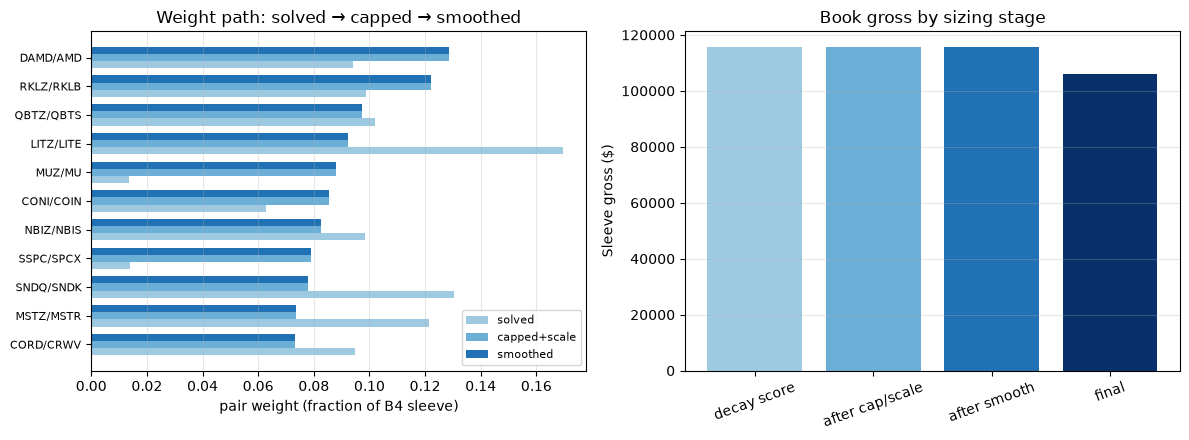

In [5]:
wf_candidates = [
    REPO / "data" / "runs" / RUN_DATE / "b4_sizing_waterfall.csv",
    REPO / "data" / "runs" / RUN_DATE / "b4_hedge_cadence" / "b4_sizing_waterfall.csv",
]
wf_path = next((p for p in wf_candidates if p.is_file()), wf_candidates[0])
if wf_path.is_file():
    wf = pd.read_csv(wf_path)
    show = [c for c in [
        "ETF", "Underlying", "weight_solved", "weight_capped", "weight_smoothed",
        "gross_decay_score_usd", "gross_after_caps_usd", "gross_after_smooth_usd",
        "gross_final_usd", "inverse_short_final_usd", "underlying_short_final_usd",
        "L", "C", "rho_effective", "crash_l_source",
    ] if c in wf.columns]
    sort_col = "weight_smoothed" if "weight_smoothed" in wf.columns else show[0]
    display(wf[show].sort_values(sort_col, ascending=False).round(4))

    stages = [
        ("decay score", "gross_decay_score_usd"),
        ("after cap/scale", "gross_after_caps_usd"),
        ("after smooth", "gross_after_smooth_usd"),
        ("final", "gross_final_usd"),
    ]
    totals = {label: float(wf[col].sum()) for label, col in stages if col in wf.columns}
    print("sleeve gross by stage:")
    for k, v in totals.items():
        print(f"  {k:16s} ${v:,.0f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    ax = axes[0]
    if {"weight_solved", "weight_capped", "weight_smoothed"}.issubset(wf.columns):
        plot_df = wf.sort_values("weight_smoothed", ascending=True).tail(12)
        y = np.arange(len(plot_df))
        h = 0.25
        ax.barh(y - h, plot_df["weight_solved"], height=h, label="solved", color="#9ecae1")
        ax.barh(y, plot_df["weight_capped"], height=h, label="capped+scale", color="#6baed6")
        ax.barh(y + h, plot_df["weight_smoothed"], height=h, label="smoothed", color="#2171b5")
        ax.set_yticks(y)
        ax.set_yticklabels(plot_df["ETF"] + "/" + plot_df["Underlying"], fontsize=8)
        ax.set_xlabel("pair weight (fraction of B4 sleeve)")
        ax.set_title("Weight path: solved → capped → smoothed")
        ax.legend(loc="lower right", fontsize=8)
        ax.grid(True, axis="x", alpha=0.3)

    ax = axes[1]
    if totals:
        ax.bar(list(totals.keys()), list(totals.values()), color=["#9ecae1", "#6baed6", "#2171b5", "#08306b"][:len(totals)])
        ax.set_ylabel("Sleeve gross ($)")
        ax.set_title("Book gross by sizing stage")
        ax.tick_params(axis="x", rotation=20)
        ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"no waterfall at {wf_path} — re-run generate_trade_plan.py for {RUN_DATE}")


## Run production historical sizing

Outputs land under `notebooks/output/production_actual_bt/` (`prod_sizing_diag.csv`,
`pair_stats.csv`, `daily_diagnostics.csv`, …). Full GTP per screened day is
slower than the old mirror path.


In [6]:
from scripts.production_actual_backtest import run_production_actual_backtest
from scripts.sizing_tilt_cadence_bt import perf
import json

outdir = OUT_BASE
summary_path = outdir / "sleeve_summary.csv"
report_path = outdir / "report.json"
if FORCE_RERUN or not summary_path.exists():
    print("===== running mode=prod =====")
    report = run_production_actual_backtest(
        run_date=RUN_DATE,
        start=START,
        outdir=outdir,
        mode="prod",
        pre_archive_policy=PRE_ARCHIVE_POLICY,
    )
else:
    report = json.loads(report_path.read_text(encoding="utf-8"))
    print(f"loaded cached prod from {outdir}")

summary = pd.read_csv(summary_path)
nav = pd.read_csv(outdir / "daily_nav.csv", index_col=0, parse_dates=True)
pair_stats_df = pd.read_csv(outdir / "pair_stats.csv") if (outdir / "pair_stats.csv").exists() else pd.DataFrame()
sleeve_pnl_df = pd.read_csv(outdir / "sleeve_pnl.csv") if (outdir / "sleeve_pnl.csv").exists() else pd.DataFrame()
pair_daily_df = (
    pd.read_csv(outdir / "pair_daily_pnl.csv", parse_dates=["date"])
    if (outdir / "pair_daily_pnl.csv").exists()
    else pd.DataFrame()
)

display(summary)
print("Book:", report.get("book"))
print("prod_stats:", report.get("prod_stats"))
print("pair_stats", len(pair_stats_df), "pair_daily rows", len(pair_daily_df))


loaded cached prod from C:\Users\drewg\Projects\quant\ls-algo\notebooks\output\production_actual_bt


,sleeve,mode,n_rebal,turnover_l1,turnover_usd,cash_days,first_plan,n_plans_used,start_usd,end_usd,...,short_proceeds_credit_annual,retarget_on_plan_change,use_resize_bands,enter_band_pct,exit_band_pct,min_trade_usd,cagr,vol,sharpe,maxdd
0,BOOK,prod,16,25.6047,"27,735,651.5344",2,2026-02-27,80,"1,050,000.0000","1,323,562.2536",...,0.0380,False,True,0.1200,0.0400,250.0000,0.8978,0.2483,2.7361,-0.0471


Book: {'cagr': 0.8977563816700336, 'vol': 0.24831933737094683, 'sharpe': 2.7360796081532786, 'maxdd': -0.04714303954199206, 'start_usd': 1050000.0, 'end_usd': 1323562.253566446, 'n_plans_used': 80, 'first_plan': '2026-02-27', 'cash_days': 2}
prod_stats: {'n_timeline': 109, 'n_sized_ok': 109, 'n_sized_fail': 0, 'b4_budget_usd': 115500.0, 'b4_gross_median': None, 'b4_gross_max': None}
pair_stats 306 pair_daily rows 19372


## Book NAV, bucket returns, and risk stats

Book NAV path, cumulative return by sleeve, and CAGR / vol / Sharpe / max drawdown
for the book and each bucket.

**Run All** from the top (keep `FORCE_RERUN=False` to load cached CSVs).
Plots use `%matplotlib inline` and render under each chart cell after execution.


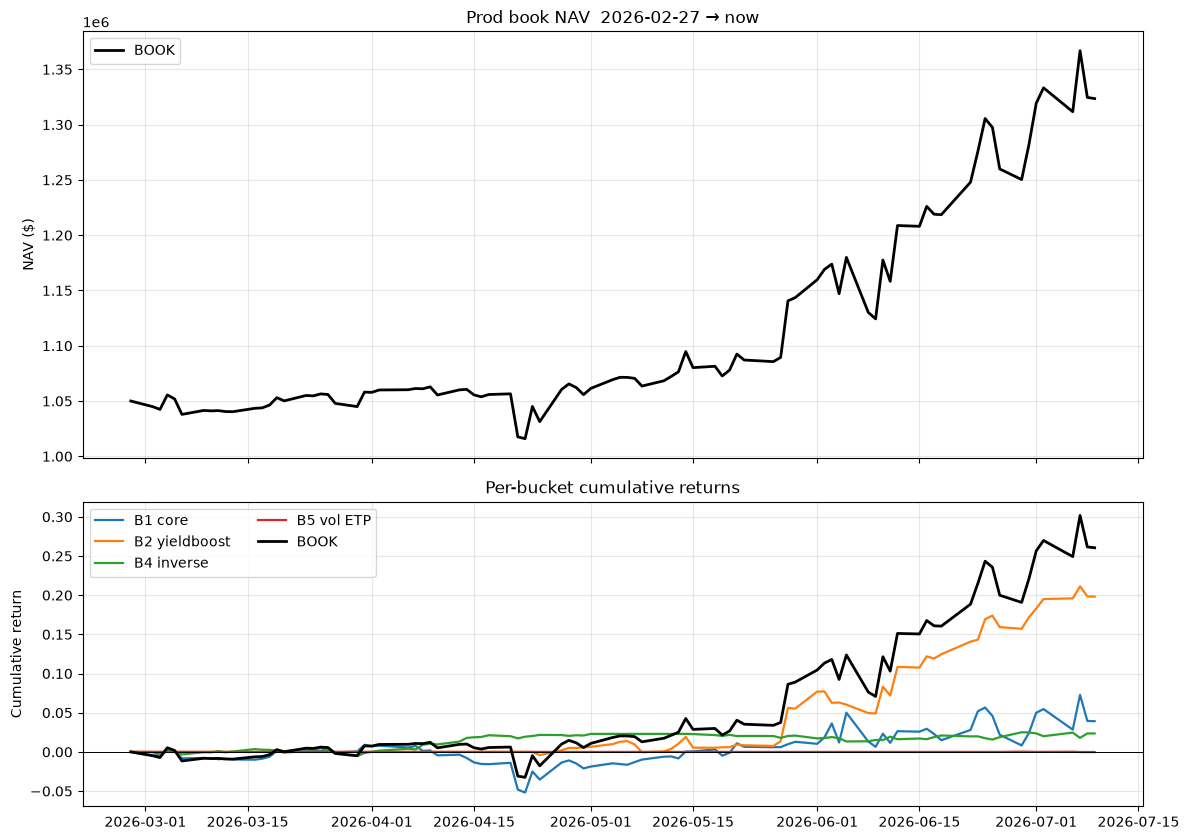

,start_usd,end_usd,total_ret,cagr,vol,sharpe,maxdd
sleeve,,,,,,,
BOOK,"1,050,000.0000","1,323,562.2536",0.2605,0.8978,0.2483,2.7361,-0.0471
B1 core,"1,050,000.0000","1,091,139.3323",0.0392,0.1122,0.1974,0.6426,-0.0604
B2 yieldboost,"1,050,000.0000","1,257,905.8870",0.1980,0.6485,0.1379,3.7386,-0.0261
B4 inverse,"1,050,000.0000","1,074,675.2276",0.0235,0.0664,0.0394,1.6706,-0.0103
B5 vol ETP,"1,050,000.0000","1,049,841.8067",-0.0002,-0.0004,0.0009,-0.4655,-0.0005


In [7]:
def _series_stats(s: pd.Series) -> dict:
    s = s.dropna()
    if len(s) < 2:
        return {"cagr": np.nan, "vol": np.nan, "sharpe": np.nan, "maxdd": np.nan,
                "total_ret": np.nan, "start_usd": np.nan, "end_usd": np.nan}
    out = perf(s)
    out["total_ret"] = float(s.iloc[-1] / s.iloc[0] - 1.0) if float(s.iloc[0]) > 0 else np.nan
    out["start_usd"] = float(s.iloc[0])
    out["end_usd"] = float(s.iloc[-1])
    return out

if nav is None or nav.empty:
    print("no daily_nav.csv — re-run the prod backtest cell above")
else:
    book_col = "BOOK_NAV" if "BOOK_NAV" in nav.columns else nav.columns[0]
    book = nav[book_col].dropna()

    fig, axes = plt.subplots(2, 1, figsize=(12, 8.5), sharex=True,
                             gridspec_kw={"height_ratios": [1.4, 1.0]})
    ax = axes[0]
    if len(book):
        ax.plot(book.index, book.values, color="black", lw=2.0, label="BOOK")
    ax.set_ylabel("NAV ($)")
    ax.set_title(f"Prod book NAV  {START} → now")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    for s in SLEEVE_ORDER:
        if s not in nav.columns:
            continue
        series = nav[s].dropna()
        if len(series) < 2 or float(series.iloc[0]) == 0:
            continue
        r = series / float(series.iloc[0]) - 1.0
        ax.plot(r.index, r.values, label=SLEEVE_LABELS[s], lw=1.6)
    if len(book) >= 2 and float(book.iloc[0]) > 0:
        br = book / float(book.iloc[0]) - 1.0
        ax.plot(br.index, br.values, label="BOOK", color="k", lw=2.0)
    ax.axhline(0, color="k", lw=0.7)
    ax.set_ylabel("Cumulative return")
    ax.set_title("Per-bucket cumulative returns")
    ax.legend(loc="best", ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    stat_rows = [{"sleeve": "BOOK", **_series_stats(book)}]
    for s in SLEEVE_ORDER:
        if s in nav.columns:
            stat_rows.append({"sleeve": SLEEVE_LABELS.get(s, s), **_series_stats(nav[s])})
    stats_tbl = pd.DataFrame(stat_rows)
    b = report.get("book") or {}
    for k in ("cagr", "vol", "sharpe", "maxdd", "end_usd"):
        if b.get(k) is not None and len(stats_tbl):
            stats_tbl.loc[stats_tbl["sleeve"] == "BOOK", k] = b.get(k)
    cols = [c for c in ["start_usd", "end_usd", "total_ret", "cagr", "vol", "sharpe", "maxdd"] if c in stats_tbl.columns]
    display(stats_tbl.set_index("sleeve")[cols].round(4))


## Production-debug ledger checks

These checks fail loudly on accounting drift. The daily ledger must reconcile
price P&L less borrow, margin, and transaction costs exactly to the NAV change.


In [8]:
diag_dir = OUT_BASE
diag_path = diag_dir / "daily_diagnostics.csv"
rebalance_path = diag_dir / "rebalance_audit.csv"

daily_diag = pd.read_csv(diag_path, parse_dates=["date"]) if diag_path.exists() else pd.DataFrame()
rebalance_diag = pd.read_csv(rebalance_path, parse_dates=["date"]) if rebalance_path.exists() else pd.DataFrame()

if daily_diag.empty:
    print(f"No production-debug ledger at {diag_path}; re-run with FORCE_RERUN=True.")
else:
    max_resid = float(daily_diag["pnl_recon_residual"].abs().max())
    print(f"mode=prod days={len(daily_diag):,}  max |P&L residual|=${max_resid:,.8f}")
    assert max_resid < 0.01, f"P&L reconciliation failed: ${max_resid:,.4f}"
    checks = pd.DataFrame({
        "check": ["P&L reconciliation", "max gross leverage", "stale-mark days", "rebalance events", "opening/resize costs"],
        "value": [
            max_resid,
            daily_diag["gross_leverage"].max(),
            int(((daily_diag["n_stale_etf"] + daily_diag["n_stale_underlying"]) > 0).sum()),
            len(rebalance_diag),
            daily_diag["daily_txn_cost"].sum(),
        ],
    })
    display(checks)


mode=prod days=91  max |P&L residual|=$0.00000000


,check,value
0,P&L reconciliation,0.0000
1,max gross leverage,4.5222
2,stale-mark days,52.0000
3,rebalance events,16.0000
4,opening/resize costs,"62,489.0888"


## Risk, leverage, and exposure dashboard

Fastest graph for an unintended leverage reset, directional drift, stuck
position count, or a drawdown that coincides with a plan switch.


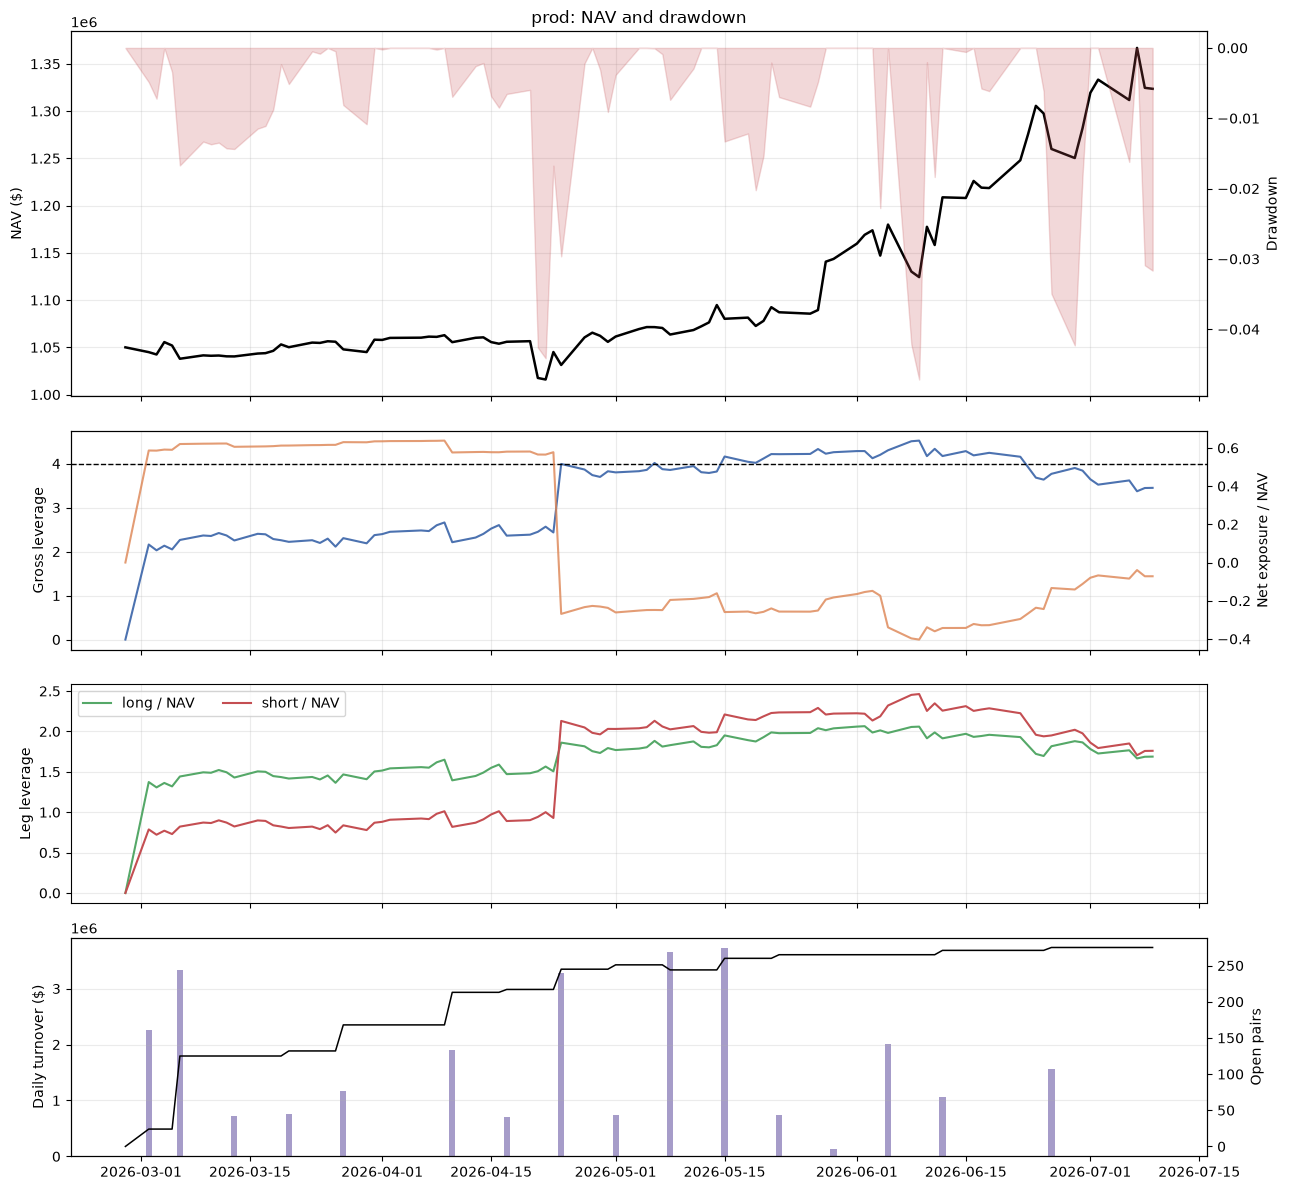

In [9]:
if not daily_diag.empty:
    d = daily_diag.set_index("date")
    fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True,
                             gridspec_kw={"height_ratios": [2.0, 1.2, 1.2, 1.2]})

    ax = axes[0]
    ax.plot(d.index, d["book_equity"], color="black", lw=1.8, label="book NAV")
    ax2 = ax.twinx()
    ax2.fill_between(d.index, d["drawdown"], 0, color="#c44e52", alpha=0.22, label="drawdown")
    ax.set_ylabel("NAV ($)")
    ax2.set_ylabel("Drawdown")
    ax.set_title("prod: NAV and drawdown")
    ax.grid(True, alpha=0.25)

    ax = axes[1]
    ax.plot(d.index, d["gross_leverage"], color="#4c72b0", label="gross / NAV")
    cfg_lev = float(report.get("gross_leverage") or np.nan)
    ax.axhline(cfg_lev, color="black", ls="--", lw=1, label=f"configured {cfg_lev:g}x")
    ax2 = ax.twinx()
    ax2.plot(d.index, d["net_exposure_pct"], color="#dd8452", alpha=0.8, label="net / NAV")
    ax.set_ylabel("Gross leverage")
    ax2.set_ylabel("Net exposure / NAV")
    ax.grid(True, alpha=0.25)

    ax = axes[2]
    eq = d["book_equity"].replace(0, np.nan)
    ax.plot(d.index, d["long_notional"] / eq, label="long / NAV", color="#55a868")
    ax.plot(d.index, d["short_notional"] / eq, label="short / NAV", color="#c44e52")
    ax.legend(loc="upper left", ncol=2)
    ax.set_ylabel("Leg leverage")
    ax.grid(True, alpha=0.25)

    ax = axes[3]
    ax.bar(d.index, d["turnover_usd"], color="#8172b2", alpha=0.7, label="turnover")
    ax2 = ax.twinx()
    ax2.plot(d.index, d["n_positions"], color="black", lw=1.1, label="positions")
    ax.set_ylabel("Daily turnover ($)")
    ax2.set_ylabel("Open pairs")
    ax.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


## P&L bridge and explicit cost drag

Gross price P&L must bridge to net P&L after borrow, margin debit, and execution
costs.


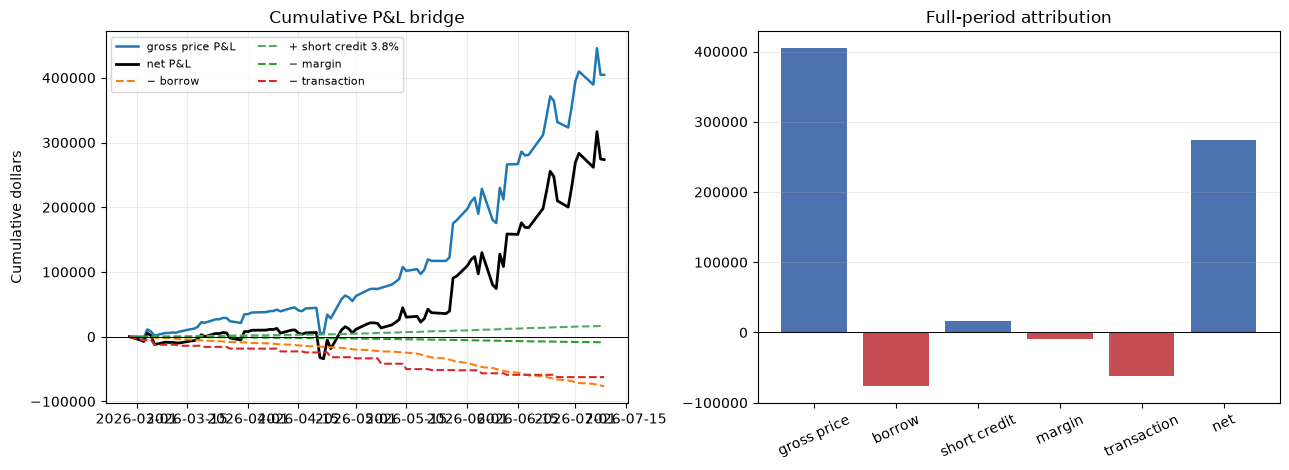

,usd
gross price,"404,659.8530"
borrow,"-76,623.4151"
short credit,"16,770.2882"
margin,"-8,755.3838"
transaction,"-62,489.0888"
net,"273,562.2536"


In [10]:
if not daily_diag.empty:
    d = daily_diag.set_index("date")
    gross_cum = d["daily_price_pnl"].cumsum()
    borrow_cum = d["daily_borrow_cost"].cumsum()
    credit_cum = d["daily_short_credit"].cumsum() if "daily_short_credit" in d.columns else 0.0
    margin_cum = d["daily_margin_cost"].cumsum()
    txn_cum = d["daily_txn_cost"].cumsum()
    net_cum = d["daily_net_pnl"].cumsum()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    ax = axes[0]
    ax.plot(d.index, gross_cum, label="gross price P&L", lw=1.8)
    ax.plot(d.index, net_cum, label="net P&L", lw=2.0, color="black")
    ax.plot(d.index, -borrow_cum, label="− borrow", ls="--")
    if "daily_short_credit" in d.columns:
        ax.plot(d.index, credit_cum, label="+ short credit 3.8%", ls="--", color="#55a868")
    ax.plot(d.index, -margin_cum, label="− margin", ls="--")
    ax.plot(d.index, -txn_cum, label="− transaction", ls="--")
    ax.axhline(0, color="black", lw=0.7)
    ax.set_title("Cumulative P&L bridge")
    ax.set_ylabel("Cumulative dollars")
    ax.legend(loc="best", ncol=2, fontsize=8)
    ax.grid(True, alpha=0.25)

    totals = pd.Series({
        "gross price": d["daily_price_pnl"].sum(),
        "borrow": -d["daily_borrow_cost"].sum(),
        "short credit": float(d["daily_short_credit"].sum()) if "daily_short_credit" in d.columns else 0.0,
        "margin": -d["daily_margin_cost"].sum(),
        "transaction": -d["daily_txn_cost"].sum(),
        "net": d["daily_net_pnl"].sum(),
    })
    colors = ["#4c72b0" if x >= 0 else "#c44e52" for x in totals]
    axes[1].bar(totals.index, totals.values, color=colors)
    axes[1].axhline(0, color="black", lw=0.7)
    axes[1].set_title("Full-period attribution")
    axes[1].tick_params(axis="x", rotation=25)
    axes[1].grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
    display(totals.rename("usd").to_frame())


## Cost-assumption sensitivity (first-order)

Holds the executed path fixed and restates only cost dollars.


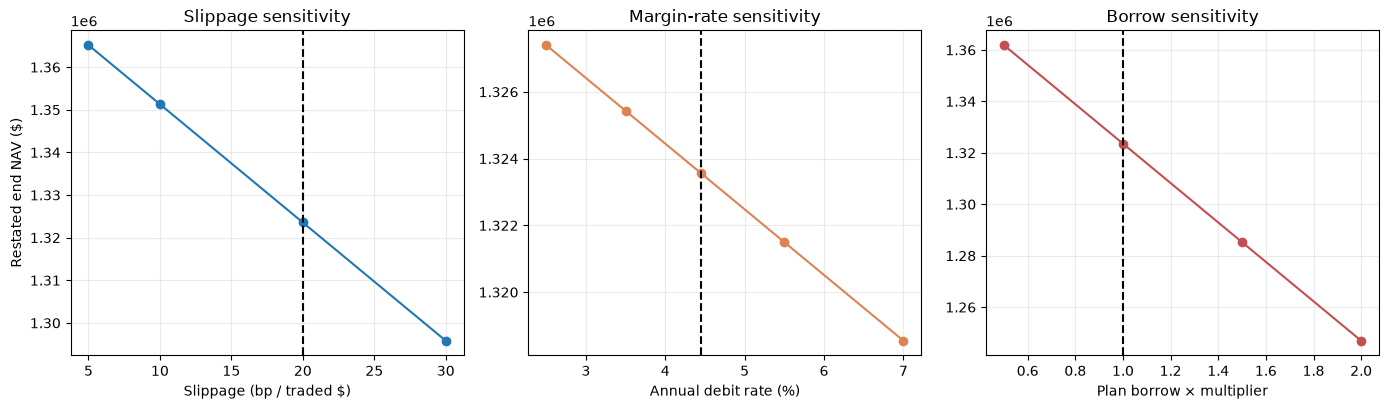

turnover=$27,735,652; implied slippage=$55,471; commission=$7,018; margin=$8,755; borrow=$76,623; short_credit=$16,770


In [11]:
if not daily_diag.empty:
    d = daily_diag.set_index("date")
    rep = report
    end_nav = float(rep["book"]["end_usd"])
    knobs = rep.get("rebalance_knobs") or {}
    current_slip_bps = float(knobs.get("slippage_bps", 20.0))
    turnover = float(d["turnover_usd"].sum())
    current_slip = turnover * current_slip_bps / 1e4
    total_txn = float(d["daily_txn_cost"].sum())
    commission = max(0.0, total_txn - current_slip)
    current_margin_rate = float(knobs.get("margin_rate_annual", 0.0445))
    current_margin = float(d["daily_margin_cost"].sum())
    current_borrow = float(d["daily_borrow_cost"].sum())
    current_credit = float(d["daily_short_credit"].sum()) if "daily_short_credit" in d.columns else 0.0

    slip_grid = np.array([5, 10, 20, 30], dtype=float)
    slip_ends = end_nav + current_slip - turnover * slip_grid / 1e4
    margin_grid = np.array([0.025, 0.035, 0.0445, 0.055, 0.07])
    margin_ends = end_nav + current_margin - current_margin * margin_grid / max(current_margin_rate, 1e-9)
    borrow_mult = np.array([0.5, 1.0, 1.5, 2.0])
    borrow_ends = end_nav + current_borrow - current_borrow * borrow_mult

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
    axes[0].plot(slip_grid, slip_ends, marker="o")
    axes[0].axvline(current_slip_bps, color="black", ls="--")
    axes[0].set_title("Slippage sensitivity")
    axes[0].set_xlabel("Slippage (bp / traded $)")
    axes[0].set_ylabel("Restated end NAV ($)")
    axes[1].plot(100 * margin_grid, margin_ends, marker="o", color="#dd8452")
    axes[1].axvline(100 * current_margin_rate, color="black", ls="--")
    axes[1].set_title("Margin-rate sensitivity")
    axes[1].set_xlabel("Annual debit rate (%)")
    axes[2].plot(borrow_mult, borrow_ends, marker="o", color="#c44e52")
    axes[2].axvline(1.0, color="black", ls="--")
    axes[2].set_title("Borrow sensitivity")
    axes[2].set_xlabel("Plan borrow × multiplier")
    for ax in axes:
        ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    print(f"turnover=${turnover:,.0f}; implied slippage=${current_slip:,.0f}; "
          f"commission=${commission:,.0f}; margin=${current_margin:,.0f}; "
          f"borrow=${current_borrow:,.0f}; short_credit=${current_credit:,.0f}")


## Plan deployment, churn, and open pair count

Middle panel now shows **open pairs** (`n_positions` from the daily ledger), not
just resize counts. High turnover previously came from retargeting on every
screened-day plan change; GTP now trades weekly (Friday) with the latest plan.


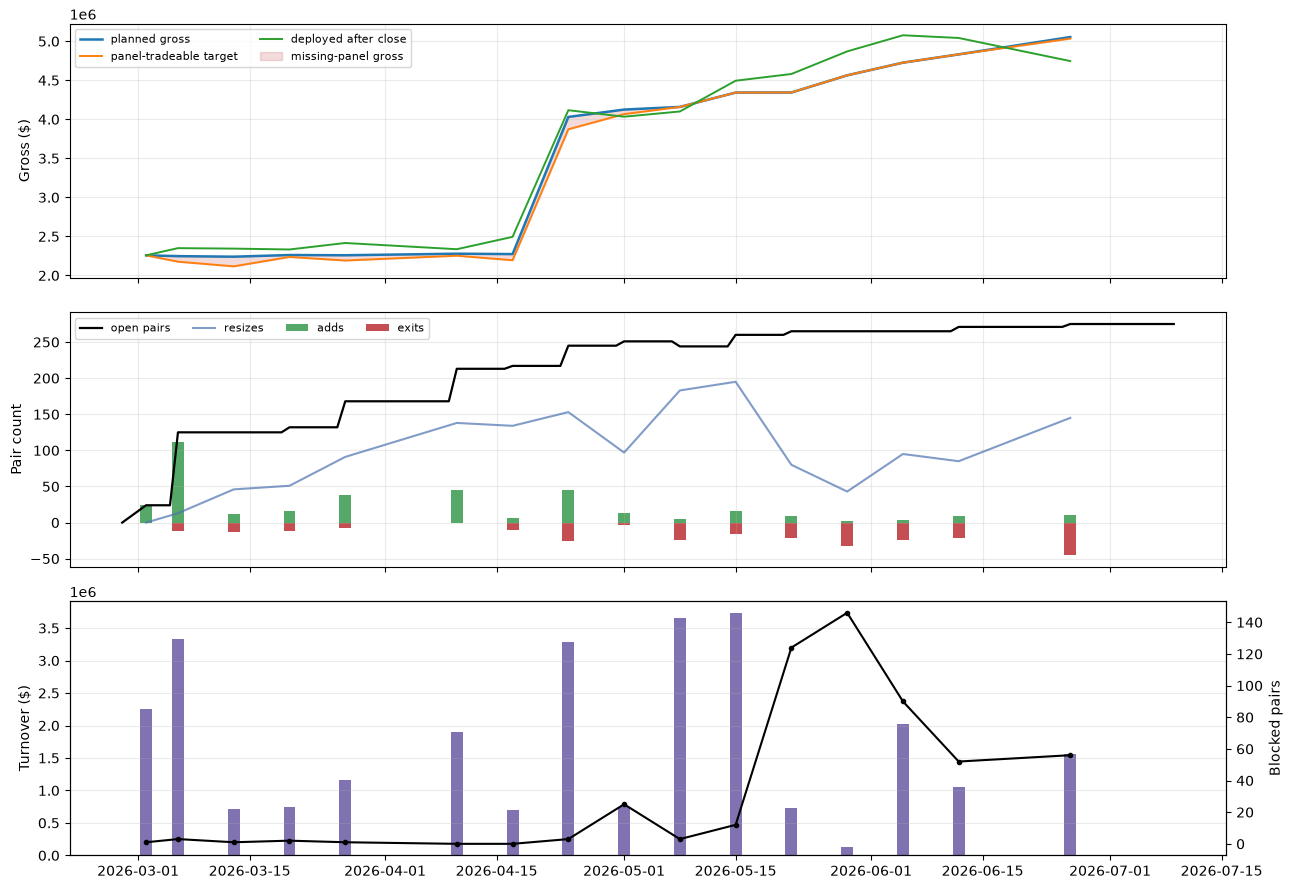

,plan_date,turnover_usd,txn_cost_usd,n_added,n_exited,n_resized,blocked_pairs,untradeable_plan_gross_usd
date,,,,,,,,
2026-05-15,2026-05-14,"3,727,546.7479","8,269.8491",16,16,195,12,0.0000
2026-05-08,2026-05-07,"3,661,265.9683","8,351.0653",5,24,183,3,0.0000
2026-03-06,2026-03-05,"3,325,602.1190","7,334.5836",111,11,13,3,"70,925.8854"
2026-04-24,2026-04-23,"3,281,832.0871","7,437.3659",45,25,153,3,"157,960.9969"
2026-03-02,2026-02-28,"2,257,500.0000","5,103.5158",24,0,0,1,0.0000
2026-06-05,2026-06-04,"2,018,209.2703","4,602.2217",4,24,95,90,0.0000
2026-04-10,2026-04-09,"1,904,171.2095","4,286.6256",45,1,138,0,"25,732.3895"
2026-06-26,2026-06-25,"1,561,140.4985","3,582.4490",10,45,145,56,"19,660.5158"
2026-03-27,2026-03-26,"1,166,613.7868","2,697.6415",38,7,91,1,"67,304.0346"


In [12]:
if not rebalance_diag.empty:
    r = rebalance_diag.set_index("date")
    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
    axes[0].plot(r.index, r["target_planned_gross_usd"], label="planned gross", lw=1.8)
    axes[0].plot(r.index, r["target_tradeable_gross_usd"], label="panel-tradeable target", lw=1.4)
    axes[0].plot(r.index, r["deployed_gross_usd"], label="deployed after close", lw=1.4)
    axes[0].fill_between(r.index, r["target_tradeable_gross_usd"], r["target_planned_gross_usd"],
                         color="#c44e52", alpha=0.2, label="missing-panel gross")
    axes[0].set_ylabel("Gross ($)")
    axes[0].legend(loc="best", ncol=2, fontsize=8)
    axes[0].grid(True, alpha=0.25)

    width = 1.5
    axes[1].bar(r.index, r.get("n_added", 0), width=width, label="adds", color="#55a868")
    axes[1].bar(r.index, -r.get("n_exited", 0), width=width, label="exits", color="#c44e52")
    if not daily_diag.empty and "n_positions" in daily_diag.columns:
        pos = daily_diag.set_index("date")["n_positions"]
        axes[1].plot(pos.index, pos.values, label="open pairs", color="black", lw=1.6)
    axes[1].plot(r.index, r.get("n_resized", 0), label="resizes", color="#4c72b0", alpha=0.7)
    axes[1].set_ylabel("Pair count")
    axes[1].legend(loc="best", ncol=4, fontsize=8)
    axes[1].grid(True, alpha=0.25)

    axes[2].bar(r.index, r["turnover_usd"], width=width, color="#8172b2", label="turnover")
    ax2 = axes[2].twinx()
    ax2.plot(r.index, r["blocked_pairs"], color="black", marker=".", label="blocked pairs")
    axes[2].set_ylabel("Turnover ($)")
    ax2.set_ylabel("Blocked pairs")
    axes[2].grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    display(r.sort_values("turnover_usd", ascending=False).head(15)[[
        "plan_date", "turnover_usd", "txn_cost_usd", "n_added", "n_exited",
        "n_resized", "blocked_pairs", "untradeable_plan_gross_usd"
    ]])


## Data quality, concentration, and event-day triage

Stale marks should cluster around genuine listing/calendar gaps, not unexplained
P&L events. Concentration should be reviewed alongside large daily moves.


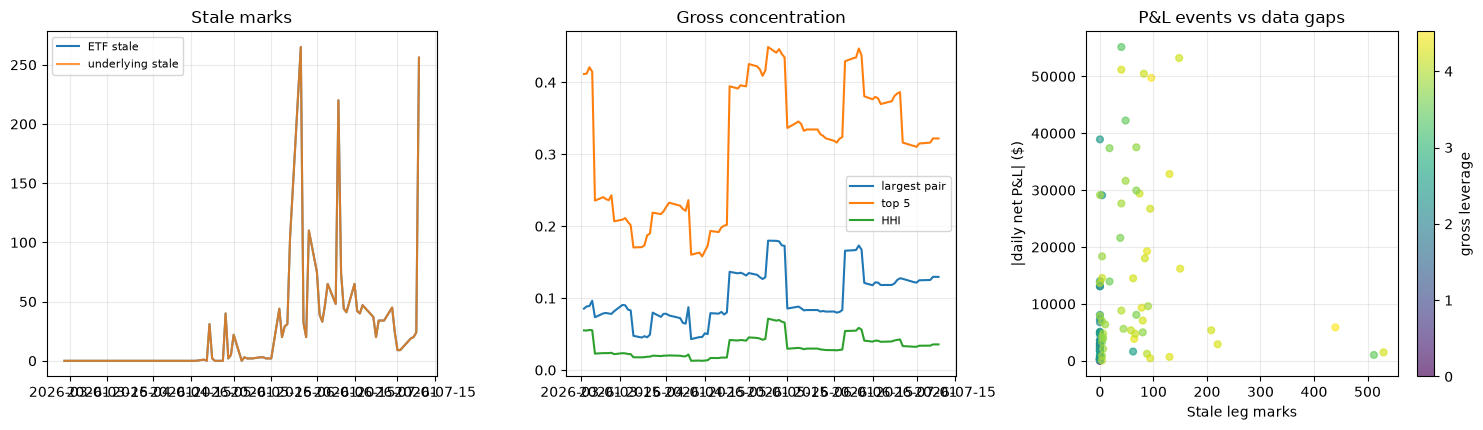

,book_equity,daily_price_pnl,daily_borrow_cost,daily_margin_cost,daily_txn_cost,daily_net_pnl,gross_leverage,n_positions,n_stale_etf,n_stale_underlying,active_plan_date
date,,,,,,,,,,,
2026-06-08,"1,130,164.4550","-48,431.8017","1,458.9840",147.4218,0.0000,"-49,745.6355",4.5079,265,48,48,2026-06-06
2026-07-08,"1,324,592.1608","-41,118.8414","1,254.7835",112.4024,0.0000,"-42,240.1670",3.4450,275,24,24,2026-07-07
2026-04-21,"1,017,571.0272","-38,569.0155",392.4894,63.7963,0.0000,"-38,924.1235",2.4492,217,0,0,2026-04-20
2026-06-26,"1,259,913.3958","-32,849.5785","1,255.8850",111.6774,"3,582.4490","-37,534.0360",3.7672,275,34,34,2026-06-25
2026-06-04,"1,147,077.2711","-25,188.3179","1,663.0292",143.6408,0.0000,"-26,730.2001",4.2000,265,47,47,2026-06-03
2026-07-06,"1,311,673.2517","-20,429.3164","1,308.8893",124.2871,0.0000,"-21,606.2452",3.6174,275,19,19,2026-07-05
2026-06-11,"1,158,259.9244","-17,987.1846","1,414.8207",141.4049,0.0000,"-19,256.3797",4.3355,265,44,44,2026-06-10
2026-05-14,"1,094,753.8377","18,640.6824",399.1490,112.2517,0.0000,"18,359.2875",3.8200,244,2,2,2026-05-13
2026-06-23,"1,275,589.3476","28,837.1360","1,329.6516",130.1758,0.0000,"27,659.0100",3.9179,271,20,20,2026-06-22


In [13]:
if not daily_diag.empty:
    d = daily_diag.set_index("date")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    axes[0].plot(d.index, d["n_stale_etf"], label="ETF stale")
    axes[0].plot(d.index, d["n_stale_underlying"], label="underlying stale", alpha=0.8)
    axes[0].set_title("Stale marks")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.25)

    axes[1].plot(d.index, d["largest_pair_gross_share"], label="largest pair")
    axes[1].plot(d.index, d["top5_gross_share"], label="top 5")
    axes[1].plot(d.index, d["gross_hhi"], label="HHI")
    axes[1].set_title("Gross concentration")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.25)

    stale_total = d["n_stale_etf"] + d["n_stale_underlying"]
    sc = axes[2].scatter(stale_total, d["daily_net_pnl"].abs(), c=d["gross_leverage"],
                         cmap="viridis", alpha=0.65, s=24)
    axes[2].set_xlabel("Stale leg marks")
    axes[2].set_ylabel("|daily net P&L| ($)")
    axes[2].set_title("P&L events vs data gaps")
    plt.colorbar(sc, ax=axes[2], label="gross leverage")
    axes[2].grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    event_cols = [c for c in [
        "book_equity", "daily_price_pnl", "daily_borrow_cost", "daily_margin_cost",
        "daily_txn_cost", "daily_net_pnl", "gross_leverage", "n_positions",
        "n_stale_etf", "n_stale_underlying", "active_plan_date",
    ] if c in d.columns]
    events = d.loc[d["daily_net_pnl"].abs().nlargest(20).index, event_cols].sort_values("daily_net_pnl")
    display(events)


## Monthly sleeve P&L heatmap


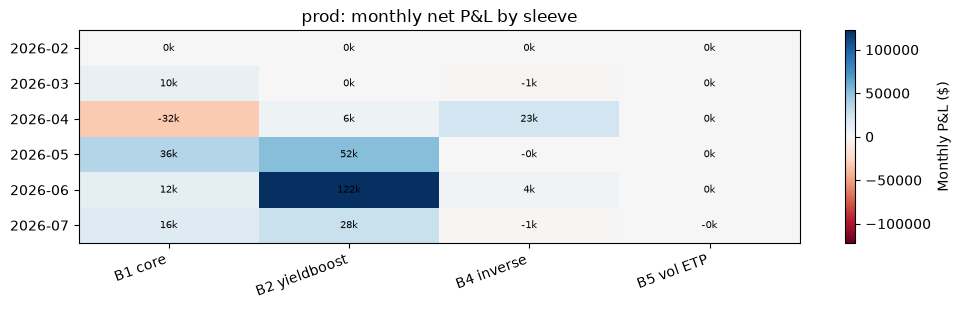

,core_leveraged,yieldboost,inverse_decay_bucket4,volatility_etp_bucket5
date,,,,
2026-02,0.0000,0.0000,0.0000,0.0000
2026-03,"9,517.0000",0.0000,"-1,457.0000",0.0000
2026-04,"-31,611.0000","5,932.0000","23,412.0000",0.0000
2026-05,"35,684.0000","52,129.0000",-69.0000,0.0000
2026-06,"11,727.0000","122,243.0000","4,245.0000",203.0000
2026-07,"15,823.0000","27,602.0000","-1,455.0000",-361.0000


In [14]:
if not daily_diag.empty:
    sd = daily_diag.set_index("date")
    sleeve_cols = [s for s in SLEEVE_ORDER if s in sd.columns]
    monthly = sd[sleeve_cols].groupby(sd.index.to_period("M")).sum()
    if not monthly.empty:
        vals = monthly.to_numpy(dtype=float)
        vmax = float(np.nanmax(np.abs(vals))) or 1.0
        fig, ax = plt.subplots(figsize=(10, max(3.2, 0.42 * len(monthly))))
        im = ax.imshow(vals, aspect="auto", cmap="RdBu", vmin=-vmax, vmax=vmax)
        ax.set_yticks(np.arange(len(monthly)))
        ax.set_yticklabels(monthly.index.astype(str))
        ax.set_xticks(np.arange(len(sleeve_cols)))
        ax.set_xticklabels([SLEEVE_LABELS.get(s, s) for s in sleeve_cols], rotation=20, ha="right")
        for i in range(vals.shape[0]):
            for j in range(vals.shape[1]):
                ax.text(j, i, f"{vals[i, j]/1000:.0f}k", ha="center", va="center", fontsize=7)
        ax.set_title("prod: monthly net P&L by sleeve")
        plt.colorbar(im, ax=ax, label="Monthly P&L ($)")
        plt.tight_layout()
        plt.show()
        display(monthly.round(0))


## Per-bucket PnL contribution


,label,n_pairs,pnl_usd
0,B1 core,272,"41,139.3323"
1,B2 yieldboost,18,"207,905.8870"
2,B4 inverse,15,"24,506.4130"
3,B5 vol ETP,1,10.6212


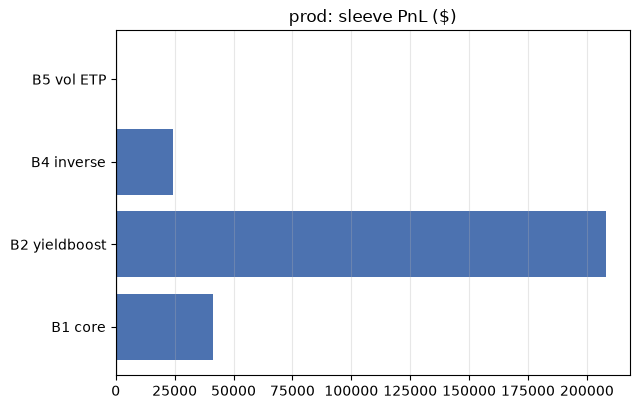

In [15]:
if sleeve_pnl_df.empty and pair_stats_df.empty:
    print("no pair/sleeve PnL artifacts — re-run with FORCE_RERUN=True")
else:
    if not sleeve_pnl_df.empty:
        sp = sleeve_pnl_df.copy()
    else:
        sp = (pair_stats_df.groupby("sleeve", as_index=False)
              .agg(n_pairs=("ETF", "count"), pnl_usd=("pnl_usd", "sum")))
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    if not sp.empty:
        sp = sp.set_index("sleeve").reindex(SLEEVE_ORDER).dropna(how="all")
        colors = ["#4c72b0" if v >= 0 else "#c44e52" for v in sp["pnl_usd"]]
        labels = [SLEEVE_LABELS.get(i, i) for i in sp.index]
        ax.barh(labels, sp["pnl_usd"], color=colors)
        ax.axvline(0, color="k", lw=0.8)
        ax.set_title("prod: sleeve PnL ($)")
        ax.grid(True, axis="x", alpha=0.3)
        display(sp.assign(label=labels)[["label", "n_pairs", "pnl_usd"]].reset_index(drop=True)
                if "n_pairs" in sp.columns else sp)
    plt.tight_layout()
    plt.show()


## Per-pair PnL by bucket (price / borrow / live divs)

Stacked components for the worst 8 + best 8 pairs per sleeve:
`price_pnl`, **borrow** (sim fee), short-credit, margin, txn, and **live IBKR
div/PIL** from `data/ledger/dividend_cash_history.csv` (cash actually booked on
that ETF — not a full sim overlay; useful for yieldboost shorts).


loaded live div/PIL for 157 symbols from dividend_cash_history.csv

=== B1 core ===


,ETF,Underlying,pnl_usd,price_pnl_usd,borrow_cost_usd,short_credit_usd,margin_cost_usd,txn_cost_usd,div_pil_live_usd,pnl_plus_live_div
3,FLYT,FLY,"-2,303.9100",123.6200,"1,559.7100",185.3300,163.6900,889.4600,0.0000,"-2,303.9100"
4,RDWU,RDW,"-2,042.4500",-148.0800,740.4800,113.7700,94.7600,"1,172.8900",0.0000,"-2,042.4500"
5,INTW,INTC,"-1,677.4100","-1,508.9000",66.3300,36.5900,31.2600,107.5100,0.0000,"-1,677.4100"
6,IREG,IREN,"-1,604.9000",-714.6100,597.0900,86.9900,87.1600,293.0300,0.0000,"-1,604.9000"
7,ONDG,ONDS,"-1,413.2700",-813.2300,441.2700,52.1600,53.9000,157.0300,0.0000,"-1,413.2700"
8,USGG,USAR,"-1,407.8500",-444.9500,762.6800,52.5000,49.9200,202.8100,0.0000,"-1,407.8500"
9,COIA,COIN,"-1,223.1100",-982.1300,154.4800,33.5300,28.3600,91.6700,-7.7800,"-1,230.8900"
10,SBTU,SBET,"-1,088.6500",-756.9200,135.3700,40.0400,39.6500,196.7400,0.0000,"-1,088.6500"
285,BMNU,BMNR,"2,486.0300","5,446.1500","1,641.2000",144.3100,114.6900,"1,348.5500",0.0000,"2,486.0300"
286,WDCX,WDC,"2,524.4400","2,665.6500",92.5200,25.6400,24.9200,49.4000,0.0000,"2,524.4400"



=== B2 yieldboost ===


,ETF,Underlying,pnl_usd,price_pnl_usd,borrow_cost_usd,short_credit_usd,margin_cost_usd,txn_cost_usd,div_pil_live_usd,pnl_plus_live_div
2,FBYY,META,"-2,355.7200","-1,596.7700",292.0500,221.1100,62.9300,625.0900,"-4,008.9800","-6,364.7000"
11,GMEY,GME,"-1,080.5900",-870.5600,0.0000,35.6100,12.0100,233.6400,0.0000,"-1,080.5900"
17,RDYY,RDDT,-906.6100,-799.4100,2.8800,9.4900,4.0900,109.7200,0.0000,-906.6100
37,DRAY,DKNG,-390.2200,-356.1900,6.7500,4.2200,1.6100,29.8800,-49.7700,-439.9900
180,AIYY,AI,29.6300,80.1300,20.8600,4.0000,1.6300,32.0200,-60.7000,-31.0700
232,HMYY,HIMS,276.7900,"4,071.3100","1,488.0000",569.4900,79.5800,"2,796.4200","-3,676.9600","-3,400.1700"
233,BBYY,BABA,294.1800,"1,110.4400",480.4700,142.1600,42.7200,435.2400,"-3,358.9000","-3,064.7200"
267,TMYY,TSM,"1,107.8000","1,683.5000",454.8400,155.6400,28.8400,247.6600,"-3,243.5800","-2,135.7800"
295,AMYY,AMD,"5,820.0200","9,326.0300","2,633.1400",400.9600,69.1400,"1,204.6900","-11,519.5100","-5,699.4900"
298,MAAY,MARA,"9,200.8400","11,242.7600",909.4600,317.8400,53.6700,"1,396.6300","-19,074.8300","-9,873.9900"



=== B4 inverse ===


,ETF,Underlying,pnl_usd,price_pnl_usd,borrow_cost_usd,short_credit_usd,margin_cost_usd,txn_cost_usd,div_pil_live_usd,pnl_plus_live_div
0,QBTZ,QBTS,"-3,860.1600","-3,292.7300",543.6700,72.0100,0.0000,95.7700,0.0000,"-3,860.1600"
1,MSDD,MSTR,"-3,214.3800","-3,068.1900",112.2000,42.4000,0.0000,76.4000,0.0000,"-3,214.3800"
13,LITZ,LITE,-990.0100,-868.6800,82.1600,23.0500,0.0000,62.2300,0.0000,-990.0100
26,RKLZ,RKLB,-610.3600,-410.7800,169.9200,13.7900,0.0000,43.4400,0.0000,-610.3600
87,CONI,COIN,-95.0000,317.0900,374.1200,30.4800,0.0000,68.4500,0.0000,-95.0000
222,SMZ,SMR,178.7500,237.4500,7.6200,6.8900,0.0000,57.9700,0.0000,178.7500
226,IREZ,IREN,191.8600,"1,058.6500",868.5400,63.7800,0.0000,62.0300,0.0000,191.8600
238,DAMD,AMD,403.7600,437.3500,12.8200,7.5800,0.0000,28.3400,0.0000,403.7600
270,SNDQ,SNDK,"1,178.6900","1,305.5300",94.9200,18.5700,0.0000,50.5000,0.0000,"1,178.6900"
271,CORD,CRWV,"1,222.3900","1,823.9600",397.7600,101.4500,0.0000,305.2600,0.0000,"1,222.3900"



=== B5 vol ETP ===


,ETF,Underlying,pnl_usd,price_pnl_usd,borrow_cost_usd,short_credit_usd,margin_cost_usd,txn_cost_usd,div_pil_live_usd,pnl_plus_live_div
161,UVIX,SVIX,10.6200,101.5800,85.7200,20.7000,0.0000,25.9400,0.0000,10.6200


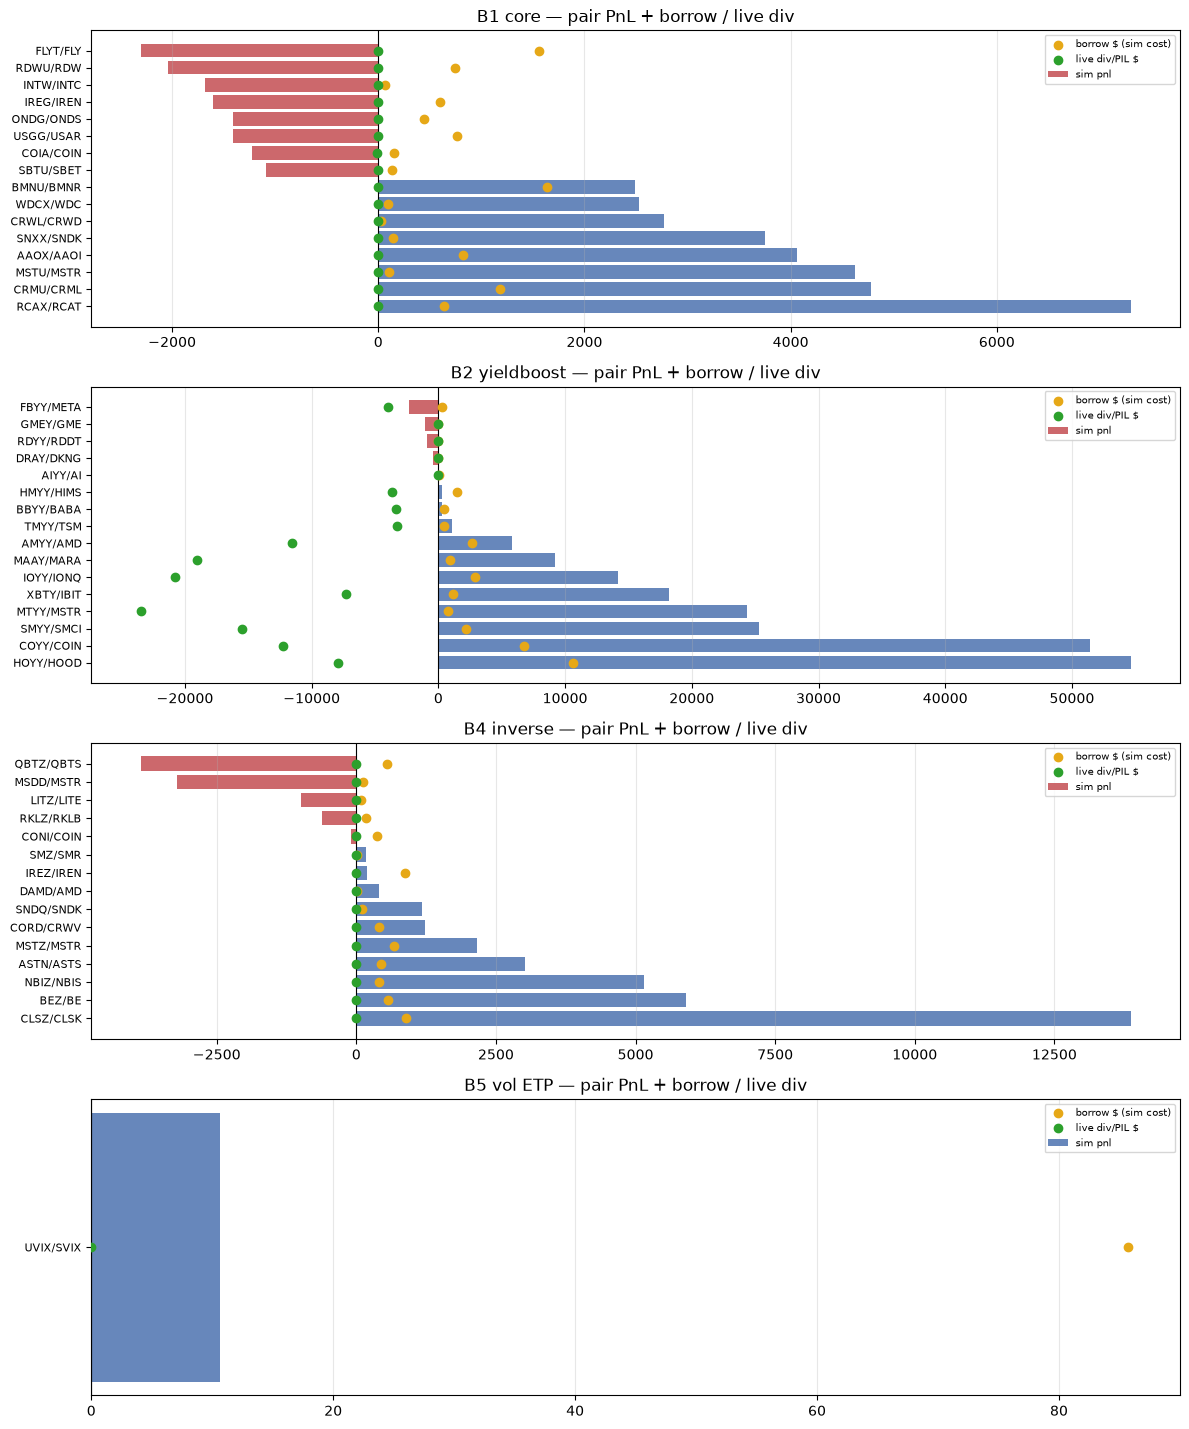

In [16]:
div_path = REPO / "data" / "ledger" / "dividend_cash_history.csv"
div_by_etf = {}
if div_path.exists():
    _div = pd.read_csv(div_path, parse_dates=["date"])
    _div["symbol"] = _div["symbol"].astype(str).str.upper()
    _div["amount_usd"] = pd.to_numeric(_div["amount_usd"], errors="coerce").fillna(0.0)
    # Window to backtest sample
    if not pair_daily_df.empty:
        d0, d1 = pair_daily_df["date"].min(), pair_daily_df["date"].max()
        _div = _div[(_div["date"] >= d0) & (_div["date"] <= d1)]
    div_by_etf = _div.groupby("symbol")["amount_usd"].sum().to_dict()
    print(f"loaded live div/PIL for {len(div_by_etf)} symbols from {div_path.name}")
else:
    print("no dividend_cash_history.csv — div column will be 0")

if pair_stats_df.empty:
    print("no pair_stats — re-run backtest")
else:
    ps = pair_stats_df.copy()
    ps["div_pil_live_usd"] = ps["ETF"].astype(str).str.upper().map(div_by_etf).fillna(0.0)
    for c in ("price_pnl_usd", "borrow_cost_usd", "short_credit_usd", "margin_cost_usd", "txn_cost_usd"):
        if c not in ps.columns:
            ps[c] = 0.0
    # Net after attaching live div/PIL (informational; sim pnl_usd excludes this)
    ps["pnl_plus_live_div"] = ps["pnl_usd"] + ps["div_pil_live_usd"]

    sleeves_present = [s for s in SLEEVE_ORDER if s in set(ps["sleeve"].astype(str))]
    n = max(1, len(sleeves_present))
    fig, axes = plt.subplots(n, 1, figsize=(12, 3.6 * n), squeeze=False)
    for ax, sleeve in zip(axes[:, 0], sleeves_present):
        sub = ps[ps["sleeve"] == sleeve].sort_values("pnl_usd")
        if len(sub) > 16:
            sub = pd.concat([sub.head(8), sub.tail(8)])
        labels = sub["ETF"].astype(str) + "/" + sub["Underlying"].astype(str)
        y = np.arange(len(sub))
        # Stack signed components around zero for readability: show net bar + borrow/div markers
        colors = ["#c44e52" if v < 0 else "#4c72b0" for v in sub["pnl_usd"]]
        ax.barh(y, sub["pnl_usd"], color=colors, alpha=0.85, label="sim pnl")
        ax.scatter(sub["borrow_cost_usd"], y, color="#e6a817", s=36, zorder=3, label="borrow $ (sim cost)")
        ax.scatter(sub["div_pil_live_usd"], y, color="#2ca02c", s=36, zorder=3, label="live div/PIL $")
        ax.axvline(0, color="k", lw=0.8)
        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=8)
        ax.invert_yaxis()
        ax.set_title(f"{SLEEVE_LABELS.get(sleeve, sleeve)} — pair PnL + borrow / live div")
        ax.grid(True, axis="x", alpha=0.3)
        ax.legend(fontsize=7, loc="best")
        print(f"\n=== {SLEEVE_LABELS.get(sleeve, sleeve)} ===")
        show = sub[[
            "ETF", "Underlying", "pnl_usd", "price_pnl_usd", "borrow_cost_usd",
            "short_credit_usd", "margin_cost_usd", "txn_cost_usd", "div_pil_live_usd",
            "pnl_plus_live_div",
        ]].sort_values("pnl_usd")
        display(show.round(2))
    plt.tight_layout()
    plt.show()


## Debug: COYY (B2) and SNDU vs SNXX (B1)

**COYY** — sim PnL is dominated by a single-day mark from a **split residual** in the
price panel (2026-06-08: heuristic applied ×5 but raw gap was ~6.06×, leaving a
~20% fake jump on a large short). Live IBKR also shows large **PIL** on COYY
(weekly distributions while short).

**SNDU vs SNXX** (both hedge SNDK) — SNDU’s panel has unadjusted jumps on
2026-04-21 (+228%) and 2026-04-27 (−72%) that SNXX does not; that alone explains
most of the PnL gap (not economics of two SNDK hedges).


=== COYY component breakdown ===


,ETF,Underlying,sleeve,sim_pnl,price_pnl,borrow,short_credit,margin,txn,live_div_pil,sim_plus_live_div,n_rebals,rebalance_dates,last_long,last_short
0,COYY,COIN,yieldboost,"51,450.7300","59,452.5700","6,767.5800","1,504.8300",328.4800,"2,410.6000","-12,295.2800","39,155.4500",5,2026-04-24;2026-05-08;2026-05-15;2026-06-05;20...,"169,655.9200","-441,272.1800"


COYY worst sim days:


,date,daily_pnl,price_pnl,borrow_cost,etf_usd,underlying_usd
18831,2026-06-11,"-16,940.4000","-16,723.5800",265.3300,"-599,906.7400","241,183.4000"
18820,2026-05-27,"-7,053.7900","-6,952.7700",122.9600,"-266,120.1500","97,720.4500"
18828,2026-06-08,"-6,524.6900","-6,304.1700",269.7400,"-609,891.1700","238,724.0900"
18848,2026-07-08,"-5,706.1400","-5,539.7500",201.8600,"-418,432.0000","172,913.0400"
18838,2026-06-23,"-2,627.9900","-2,454.8000",209.7200,"-434,733.9700","167,276.5200"


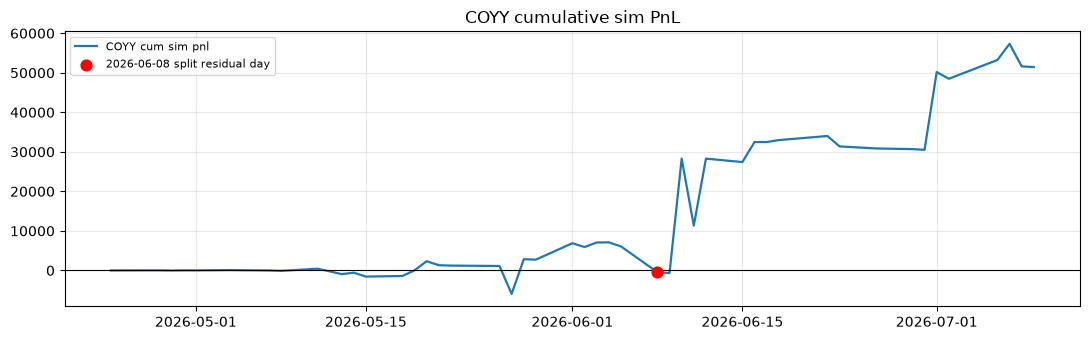


=== SNDU vs SNXX (both SNDK) ===


,ETF,Underlying,sleeve,sim_pnl,price_pnl,borrow,short_credit,margin,txn,live_div_pil,sim_plus_live_div,n_rebals,rebalance_dates,last_long,last_short
0,SNDU,SNDK,core_leveraged,"2,009.7600","2,422.5300",176.5800,46.3400,50.0100,232.5200,0.0000,"2,009.7600",5,2026-04-17;2026-04-24;2026-05-15;2026-06-05;20...,"13,131.6700","-6,592.4400"
1,SNXX,SNDK,core_leveraged,"3,750.5500","4,034.6500",139.4200,55.1400,60.5100,139.3100,0.0000,"3,750.5500",8,2026-04-24;2026-05-01;2026-05-08;2026-05-22;20...,"14,747.4500","-7,415.9800"


[SPLIT][apply] ABNY 2024-06-25 factor=x5 source=heuristic — ratio=5.0588 matched=5 prev=$20.0000 cur=$101.1750
[SPLIT][crater] APLZ repaired 2026-06-03..2026-06-04 (anchor=$13.3000 → recover=$18.6300 on 2026-06-05)
[SPLIT][self-heal] APLZ 2026-06-03 SKIPPED (source=flex, factor=5, pre=$13.3000 post=$14.8812 ratio=1.119)
[SPLIT][self-heal] APLZ 2026-02-06 SKIPPED (source=heuristic, factor=0.5, pre=$152.6000 post=$74.8000 ratio=0.490)
[SPLIT][self-heal] APLZ 2026-05-21 SKIPPED (source=heuristic, factor=0.5, pre=$24.0500 post=$13.7000 ratio=0.570)
[SPLIT][self-heal] APPX 2026-03-10 SKIPPED (source=flex, factor=3, pre=$48.1500 post=$40.6700 ratio=0.845)
[SPLIT][self-heal] BAIG 2026-05-05 SKIPPED (source=flex, factor=10, pre=$37.8900 post=$37.5150 ratio=0.990)
[SPLIT][apply] BAIG 2026-04-16 factor=x0.1 source=heuristic — ratio=0.0979 matched=0.1 prev=$32.7000 cur=$3.2000
[SPLIT][apply] BAIG 2026-05-04 factor=x10 source=heuristic — ratio=10.1855 matched=10 prev=$3.7200 cur=$37.8900
[SPLIT][c

[SPLIT][self-heal] BEZ 2026-04-14 SKIPPED (source=heuristic, factor=0.5, pre=$99.5000 post=$51.5000 ratio=0.518)
[SPLIT][self-heal] BEZ 2026-04-29 SKIPPED (source=heuristic, factor=0.5, pre=$46.8000 post=$21.3000 ratio=0.455)
[SPLIT][self-heal] BMNG 2026-05-05 SKIPPED (source=flex, factor=20, pre=$30.6000 post=$31.4700 ratio=1.028)
[SPLIT][apply] BMNG 2026-04-16 factor=x0.05 source=heuristic — ratio=0.0503 matched=0.05 prev=$30.4000 cur=$1.5300
[SPLIT][apply] BMNG 2026-05-04 factor=x20 source=heuristic — ratio=21.7021 matched=20 prev=$1.4100 cur=$30.6000
[SPLIT][crater] BULG repaired 2026-04-16..2026-04-22 (anchor=$36.4000 → recover=$41.1600 on 2026-04-23)
[SPLIT][self-heal] BULG 2026-04-24 SKIPPED (source=flex, factor=20, pre=$41.1600 post=$40.9660 ratio=0.995)
[SPLIT][self-heal] CCUP 2026-02-25 SKIPPED (source=heuristic, factor=2, pre=$2.3600 post=$4.0400 ratio=1.712)
[SPLIT][self-heal] COIA 2026-05-28 SKIPPED (source=flex, factor=2, pre=$9.8400 post=$10.7300 ratio=1.090)
[SPLIT][sel

[SPLIT][apply] CRCD 2026-02-25 factor=x0.333333 source=heuristic — ratio=0.2890 matched=0.333333 prev=$43.5700 cur=$12.5900
[SPLIT][self-heal] CRCG 2026-05-05 SKIPPED (source=flex, factor=10, pre=$38.3000 post=$34.9200 ratio=0.912)
[SPLIT][self-heal] CRCG 2026-02-25 SKIPPED (source=heuristic, factor=2, pre=$139.0000 post=$239.0000 ratio=1.719)
[SPLIT][apply] CRCG 2026-04-16 factor=x0.1 source=heuristic — ratio=0.1037 matched=0.1 prev=$320.0000 cur=$33.2000
[SPLIT][self-heal] CRDU 2026-03-10 SKIPPED (source=flex, factor=3, pre=$24.3600 post=$22.7800 ratio=0.935)
[SPLIT][self-heal] CRWG 2026-05-05 SKIPPED (source=flex, factor=10, pre=$58.1000 post=$60.1700 ratio=1.036)
[SPLIT][apply] CRWG 2026-04-16 factor=x0.1 source=heuristic — ratio=0.1015 matched=0.1 prev=$539.0000 cur=$54.7000
[SPLIT][self-heal] CWEB 2022-03-16 SKIPPED (source=heuristic, factor=2, pre=$37.5464 post=$67.7096 ratio=1.803)
[SPLIT][self-heal] DJTU 2025-12-18 SKIPPED (source=heuristic, factor=2, pre=$2.8100 post=$5.1600 

...

[SPLIT][self-heal] SRPU 2025-11-04 SKIPPED (source=heuristic, factor=0.333333, pre=$29.2200 post=$9.8800 ratio=0.338)
[SPLIT][self-heal] SRPU 2026-03-25 SKIPPED (source=heuristic, factor=2, pre=$8.8280 post=$14.9400 ratio=1.692)
[SPLIT][self-heal] STLU 2026-06-01 SKIPPED (source=heuristic, factor=2, pre=$18.0700 post=$39.3800 ratio=2.179)
[SPLIT][self-heal] TEMT 2026-03-10 SKIPPED (source=flex, factor=3, pre=$24.5400 post=$23.2300 ratio=0.947)


[SPLIT][crater] TSYY repaired 2026-05-27..2026-06-01 (anchor=$3.0350 → recover=$2.9825 on 2026-06-02)
[SPLIT][self-heal] TSYY 2026-06-02 SKIPPED (source=flex, factor=8, pre=$2.9955 post=$2.9825 ratio=0.996)
[SPLIT][apply] TSYY 2026-06-08 factor=x8 source=splits_overrides_csv — GraniteShares TSYY residual 1-for-8 (flex dated 06-02 self-healed after crater; raw 06-08 gap ~8.21x)
[SPLIT][apply] TXXS 2026-06-24 factor=x10 source=heuristic — ratio=8.6397 matched=10 prev=$2.3010 cur=$19.8800


[SPLIT][self-heal] UNX 2026-03-10 SKIPPED (source=flex, factor=10, pre=$29.1000 post=$27.3490 ratio=0.940)
[SPLIT][self-heal] UNX 2026-01-30 SKIPPED (source=heuristic, factor=0.5, pre=$142.0000 post=$73.1000 ratio=0.515)
[SPLIT][self-heal] UNX 2026-02-11 SKIPPED (source=heuristic, factor=0.5, pre=$69.7000 post=$31.4000 ratio=0.451)
[SPLIT][self-heal] UVIX 2026-07-01 SKIPPED (source=flex, factor=20, pre=$61.8000 post=$62.4800 ratio=1.011)
[SPLIT][self-heal] UVIX 2024-08-05 SKIPPED (source=heuristic, factor=2, pre=$104.0000 post=$191.8000 ratio=1.844)
[SPLIT][self-heal] UVIX 2025-04-09 SKIPPED (source=heuristic, factor=0.5, pre=$92.3700 post=$51.9150 ratio=0.562)
[SPLIT][apply] UVIX 2026-06-24 factor=x20 source=heuristic — ratio=19.7245 matched=20 prev=$3.6300 cur=$71.6000
[SPLIT][self-heal] UXRP 2026-05-28 SKIPPED (source=flex, factor=5, pre=$16.9500 post=$16.6800 ratio=0.984)
[SPLIT][self-heal] UXRP 2026-02-05 SKIPPED (source=heuristic, factor=0.5, pre=$5.9300 post=$3.2500 ratio=0.548)

[SPLIT][self-heal] WDCX 2026-06-03 SKIPPED (source=heuristic, factor=0.333333, pre=$36.7533 post=$13.6400 ratio=0.371)
[SPLIT][self-heal] WEBS 2020-03-16 SKIPPED (source=heuristic, factor=2, pre=$2324.2471 post=$4142.8472 ratio=1.782)
[SPLIT][crater] XXRP repaired 2026-06-03..2026-06-11 (anchor=$33.7000 → recover=$25.6000 on 2026-06-12)
[SPLIT][crater] XXRP repaired 2026-06-17..2026-06-17 (anchor=$31.4000 → recover=$26.8000 on 2026-06-18)
[SPLIT][crater] XXRP repaired 2026-06-22..2026-06-22 (anchor=$26.8000 → recover=$24.7000 on 2026-06-23)
[SPLIT][self-heal] XXRP 2026-06-29 SKIPPED (source=flex, factor=10, pre=$20.6000 post=$21.7200 ratio=1.054)
[SPLIT][self-heal] XXRP 2026-02-05 SKIPPED (source=heuristic, factor=0.5, pre=$6.1900 post=$3.3900 ratio=0.548)
[SPLIT][apply] XXRP 2026-05-18 factor=x10 source=heuristic — ratio=10.0000 matched=10 prev=$4.1600 cur=$41.6000


[SPLIT][self-heal] YINN 2022-03-16 SKIPPED (source=heuristic, factor=2, pre=$57.5108 post=$94.6801 ratio=1.646)


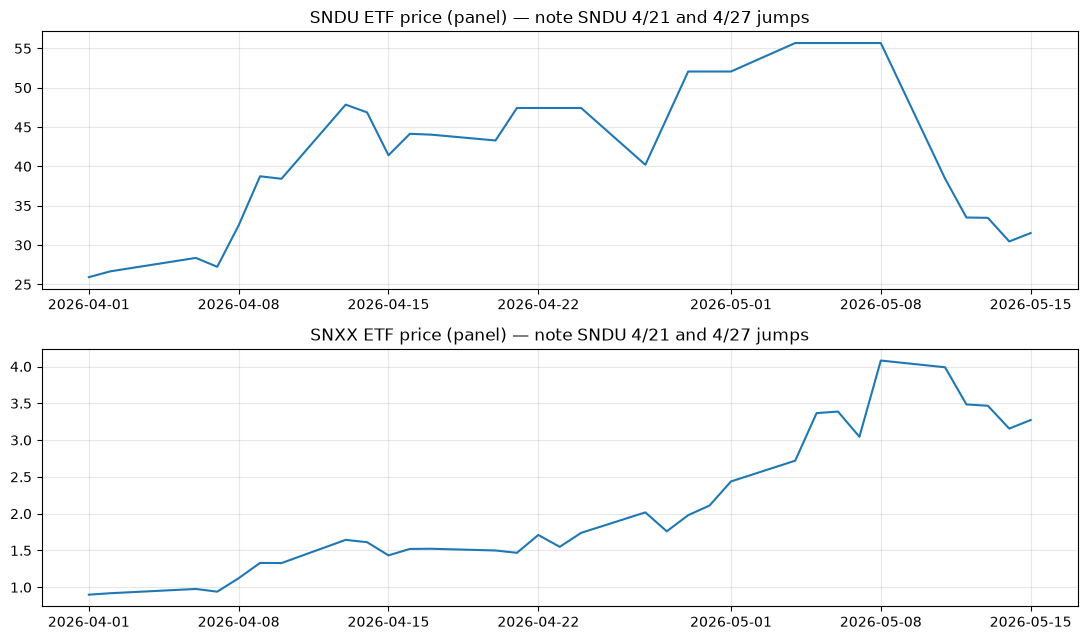

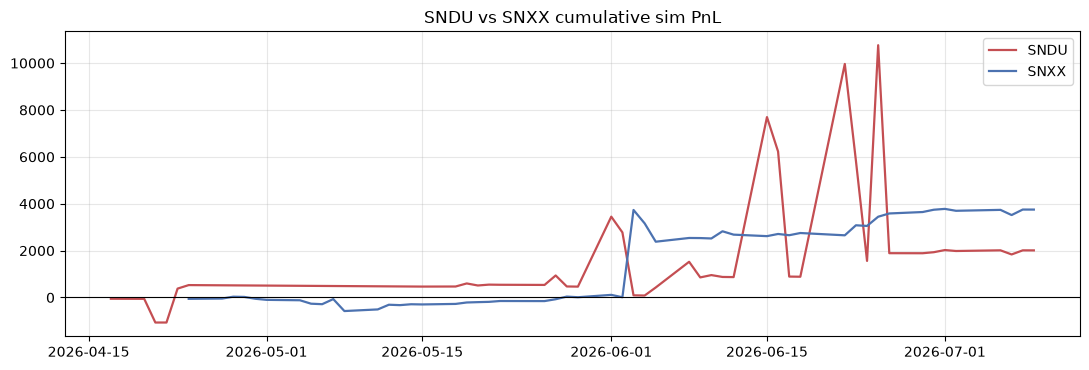

In [17]:
from scripts.production_actual_backtest import load_price_panel

ps = pair_stats_df.copy() if not pair_stats_df.empty else pd.DataFrame()
pdaily = pair_daily_df.copy() if not pair_daily_df.empty else pd.DataFrame()

def _pair_breakdown(etf: str) -> pd.DataFrame:
    row = ps[ps["ETF"].astype(str) == etf]
    if row.empty:
        print(etf, "not in pair_stats")
        return pd.DataFrame()
    r = row.iloc[0]
    live_div = float(div_by_etf.get(etf, 0.0))
    out = pd.DataFrame([{
        "ETF": etf,
        "Underlying": r.get("Underlying"),
        "sleeve": r.get("sleeve"),
        "sim_pnl": float(r["pnl_usd"]),
        "price_pnl": float(r.get("price_pnl_usd", 0) or 0),
        "borrow": float(r.get("borrow_cost_usd", 0) or 0),
        "short_credit": float(r.get("short_credit_usd", 0) or 0),
        "margin": float(r.get("margin_cost_usd", 0) or 0),
        "txn": float(r.get("txn_cost_usd", 0) or 0),
        "live_div_pil": live_div,
        "sim_plus_live_div": float(r["pnl_usd"]) + live_div,
        "n_rebals": int(r.get("n_rebals", 0) or 0),
        "rebalance_dates": r.get("rebalance_dates", ""),
        "last_long": float(r.get("long_usd", 0) or 0),
        "last_short": float(r.get("short_usd", 0) or 0),
    }])
    return out

print("=== COYY component breakdown ===")
display(_pair_breakdown("COYY").round(2))

if not pdaily.empty and (pdaily["ETF"] == "COYY").any():
    coy = pdaily[pdaily["ETF"] == "COYY"].sort_values("date")
    worst = coy.nsmallest(5, "daily_pnl")[["date", "daily_pnl", "price_pnl", "borrow_cost", "etf_usd", "underlying_usd"]]
    print("COYY worst sim days:")
    display(worst.round(2))
    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.plot(coy["date"], coy["cum_pnl"], lw=1.6, label="COYY cum sim pnl")
    ax.axhline(0, color="k", lw=0.8)
    # mark 2026-06-08
    hit = coy[coy["date"] == "2026-06-08"]
    if len(hit):
        ax.scatter(hit["date"], hit["cum_pnl"], color="red", s=60, zorder=3, label="2026-06-08 split residual day")
    ax.set_title("COYY cumulative sim PnL")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n=== SNDU vs SNXX (both SNDK) ===")
cmp = pd.concat([_pair_breakdown("SNDU"), _pair_breakdown("SNXX")], ignore_index=True)
display(cmp.round(2))

panel = load_price_panel(RUN_DATE)
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=False)
for ax, etf in zip(axes, ["SNDU", "SNXX"]):
    if etf not in panel:
        ax.set_title(f"{etf} missing from price panel")
        continue
    px = panel[etf]["a_px"].loc["2026-04-01":"2026-05-15"]
    ax.plot(px.index, px.values, lw=1.5)
    ax.set_title(f"{etf} ETF price (panel) — note SNDU 4/21 and 4/27 jumps")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if not pdaily.empty:
    fig, ax = plt.subplots(figsize=(11, 3.8))
    for etf, color in [("SNDU", "#c44e52"), ("SNXX", "#4c72b0")]:
        sub = pdaily[pdaily["ETF"] == etf].sort_values("date")
        if sub.empty:
            continue
        ax.plot(sub["date"], sub["cum_pnl"], lw=1.6, color=color, label=etf)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title("SNDU vs SNXX cumulative sim PnL")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Top / bottom 5 pairs by sleeve (exposure + hedge + rebals)

For each sleeve: worst 5 and best 5 by `pnl_usd`, with charts for PnL, long/short
exposure, and hedge ratio, plus a table of rebalance dates.
(`long_usd` = underlying target, `short_usd` = ETF target;
`hedge_ratio` = `|underlying| / |ETF|`.)


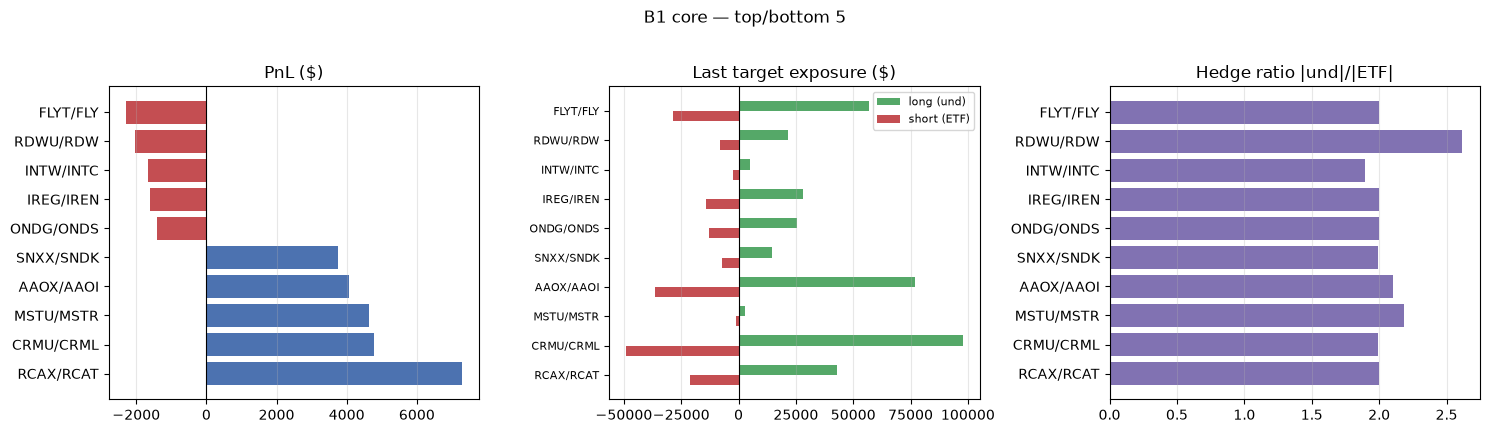


=== B1 core — top/bottom 5 ===


,rank,ETF,Underlying,pnl_usd,long_usd,short_usd,hedge_ratio,Delta,n_rebals,rebalance_dates,end_weight
0,bottom_1,FLYT,FLY,"-2,303.9138","57,020.7639","-28,566.0000",1.9961,1.9961,14,2026-03-06;2026-03-13;2026-03-20;2026-04-10;20...,0.0655
1,bottom_2,RDWU,RDW,"-2,042.4472","21,397.9177","-8,176.1335",2.6171,1.9944,9,2026-03-02;2026-03-06;2026-03-27;2026-04-10;20...,0.0000
2,bottom_3,INTW,INTC,"-1,677.4108","4,943.1454","-2,611.5651",1.8928,1.9873,12,2026-03-06;2026-03-13;2026-03-20;2026-03-27;20...,0.0045
3,bottom_4,IREG,IREN,"-1,604.8993","28,319.1694","-14,191.3734",1.9955,1.9955,10,2026-03-20;2026-03-27;2026-04-10;2026-04-17;20...,0.0265
4,bottom_5,ONDG,ONDS,"-1,413.2710","25,491.8883","-12,769.6190",1.9963,1.9963,11,2026-04-10;2026-04-17;2026-04-24;2026-05-01;20...,0.0269
5,top_1,RCAX,RCAT,"7,296.5410","42,768.3018","-21,360.5581",2.0022,2.0022,9,2026-03-27;2026-04-10;2026-04-24;2026-05-08;20...,0.0486
6,top_2,CRMU,CRML,"4,775.8585","97,755.4111","-49,086.1745",1.9915,1.9915,11,2026-03-02;2026-03-06;2026-03-27;2026-04-10;20...,0.0961
7,top_3,MSTU,MSTR,"4,623.8345","2,850.2344","-1,305.2659",2.1836,1.9934,8,2026-04-10;2026-04-17;2026-04-24;2026-05-01;20...,0.0037
8,top_4,AAOX,AAOI,"4,062.0027","76,990.3858","-36,640.5425",2.1012,1.9933,4,2026-05-22;2026-05-29;2026-06-12;2026-06-26,0.0677
9,top_5,SNXX,SNDK,"3,750.5481","14,747.4460","-7,415.9830",1.9886,1.9886,8,2026-04-24;2026-05-01;2026-05-08;2026-05-22;20...,0.0127


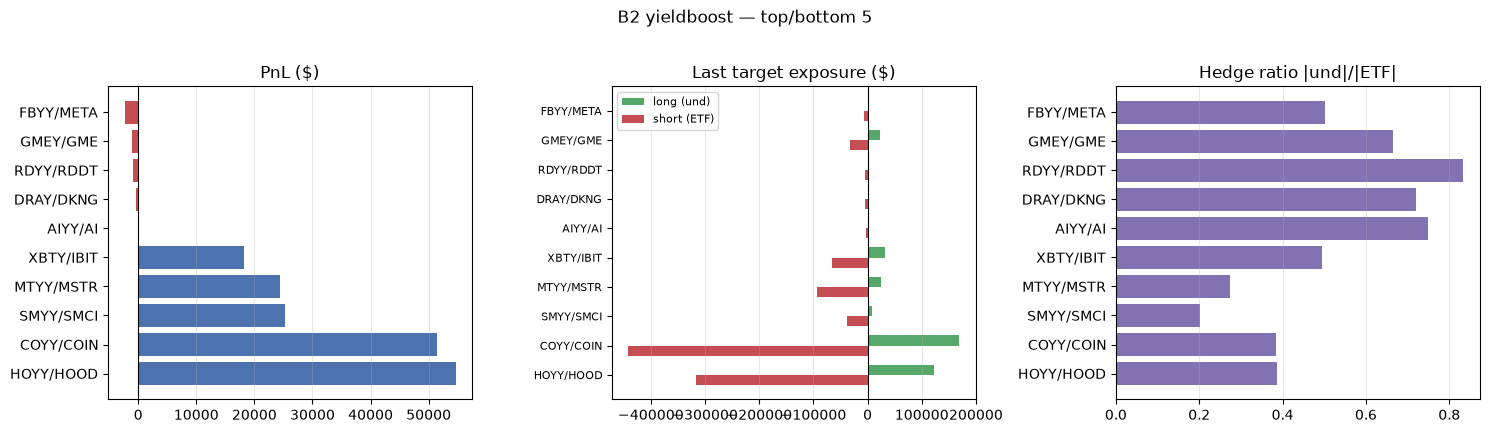


=== B2 yieldboost — top/bottom 5 ===


,rank,ETF,Underlying,pnl_usd,long_usd,short_usd,hedge_ratio,Delta,n_rebals,rebalance_dates,end_weight
0,bottom_1,FBYY,META,"-2,355.7182","3,548.0305","-7,067.4752",0.5020,0.4853,5,2026-04-24;2026-05-08;2026-05-15;2026-06-05;20...,0.0085
1,bottom_2,GMEY,GME,"-1,080.5946","22,061.9390","-33,127.4272",0.6660,0.6660,2,2026-04-24;2026-05-08,0.0000
2,bottom_3,RDYY,RDDT,-906.6095,"3,205.8454","-3,852.7783",0.8321,0.8204,3,2026-04-24;2026-05-01;2026-05-08,0.0000
3,bottom_4,DRAY,DKNG,-390.2206,"2,846.3143","-3,946.5264",0.7212,0.8026,2,2026-04-24;2026-05-08,0.0000
4,bottom_5,AIYY,AI,29.6281,"2,831.7388","-3,777.0273",0.7497,0.7705,2,2026-04-24;2026-05-08,0.0000
5,top_1,HOYY,HOOD,"54,622.0597","121,945.8452","-315,755.6103",0.3862,0.3571,3,2026-05-15;2026-06-05;2026-06-12,0.3565
6,top_2,COYY,COIN,"51,450.7310","169,655.9161","-441,272.1827",0.3845,0.3845,5,2026-04-24;2026-05-08;2026-05-15;2026-06-05;20...,0.4468
7,top_3,SMYY,SMCI,"25,287.9570","7,770.8616","-38,338.8053",0.2027,0.2156,4,2026-04-24;2026-05-08;2026-05-15;2026-06-05,0.0314
8,top_4,MTYY,MSTR,"24,385.0854","25,373.1049","-93,057.1996",0.2727,0.3494,5,2026-04-24;2026-05-08;2026-05-15;2026-06-05;20...,0.0941
9,top_5,XBTY,IBIT,"18,229.4864","32,703.7306","-66,248.4187",0.4937,0.4937,6,2026-04-24;2026-05-08;2026-05-15;2026-06-05;20...,0.0774


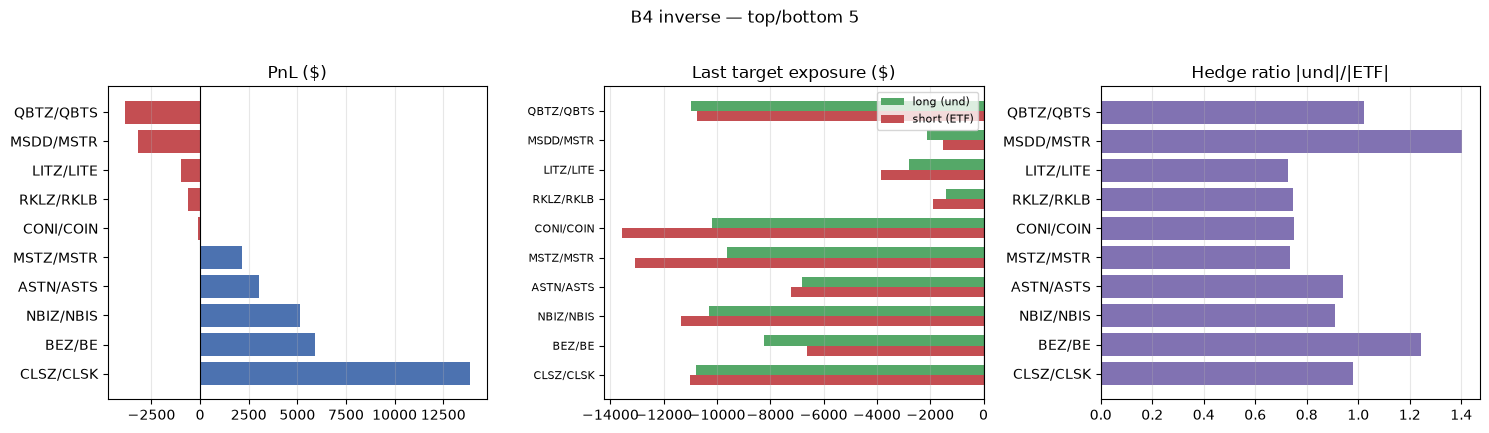


=== B4 inverse — top/bottom 5 ===


,rank,ETF,Underlying,pnl_usd,long_usd,short_usd,hedge_ratio,Delta,n_rebals,rebalance_dates,end_weight
0,bottom_1,QBTZ,QBTS,"-3,860.1623","-10,976.8421","-10,739.0158",1.0221,-1.9972,6,2026-05-15;2026-05-22;2026-05-29;2026-06-05;20...,0.0169
1,bottom_2,MSDD,MSTR,"-3,214.3850","-2,108.1096","-1,502.9786",1.4026,-1.9773,3,2026-05-15;2026-06-05;2026-06-12,0.0026
2,bottom_3,LITZ,LITE,-990.0144,"-2,804.6309","-3,846.9731",0.7290,-1.9998,2,2026-06-12;2026-06-26,0.0055
3,bottom_4,RKLZ,RKLB,-610.3620,"-1,411.6541","-1,889.9565",0.7469,-2.0058,4,2026-05-22;2026-05-29;2026-06-05;2026-06-12,0.0024
4,bottom_5,CONI,COIN,-95.0000,"-10,194.5413","-13,555.1663",0.7521,-1.9251,4,2026-05-15;2026-06-05;2026-06-12;2026-06-26,0.0174
5,top_1,CLSZ,CLSK,"13,862.3359","-10,797.0994","-11,014.4201",0.9803,-2.0255,8,2026-03-02;2026-03-06;2026-03-13;2026-03-20;20...,0.0161
6,top_2,BEZ,BE,"5,906.5829","-8,232.4486","-6,625.9740",1.2425,-2.0132,3,2026-04-10;2026-04-17;2026-05-22,0.0106
7,top_3,NBIZ,NBIS,"5,158.8420","-10,306.7428","-11,350.7437",0.9080,-2.0371,5,2026-04-10;2026-05-01;2026-05-15;2026-05-29;20...,0.0158
8,top_4,ASTN,ASTS,"3,013.7327","-6,805.5088","-7,233.9760",0.9408,-2.0021,4,2026-05-22;2026-05-29;2026-06-05;2026-06-12,0.0094
9,top_5,MSTZ,MSTR,"2,159.3923","-9,623.7601","-13,089.4230",0.7352,-1.9882,8,2026-03-02;2026-03-06;2026-04-10;2026-04-17;20...,0.0151


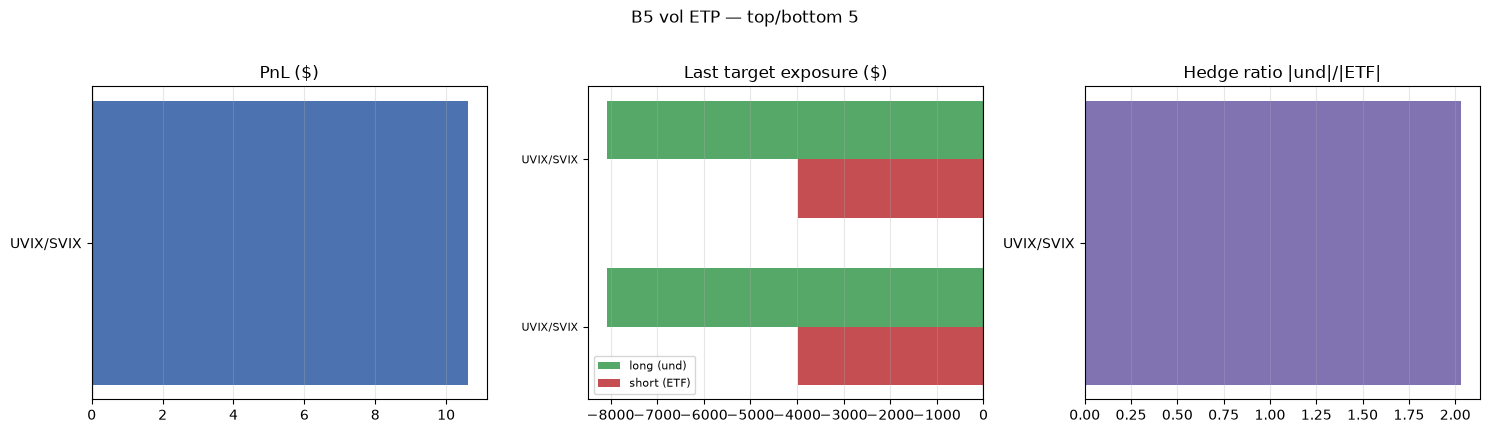


=== B5 vol ETP — top/bottom 5 ===


,rank,ETF,Underlying,pnl_usd,long_usd,short_usd,hedge_ratio,Delta,n_rebals,rebalance_dates,end_weight
0,bottom_1,UVIX,SVIX,10.6212,"-8,074.7523","-3,973.7581",2.0320,-1.9914,3,2026-05-22;2026-06-12;2026-06-26,0.0092
1,top_1,UVIX,SVIX,10.6212,"-8,074.7523","-3,973.7581",2.0320,-1.9914,3,2026-05-22;2026-06-12;2026-06-26,0.0092


In [18]:
need = {"long_usd", "short_usd", "hedge_ratio", "rebalance_dates", "pnl_usd"}
if pair_stats_df.empty:
    print("no pair_stats — re-run backtest")
elif not need.issubset(pair_stats_df.columns):
    print(
        "pair_stats missing exposure/rebal columns — re-run with FORCE_RERUN=True "
        f"(have={sorted(pair_stats_df.columns)})"
    )
else:
    ps = pair_stats_df.copy()
    show_cols = [
        c for c in [
            "rank", "ETF", "Underlying", "pnl_usd",
            "long_usd", "short_usd", "hedge_ratio", "Delta",
            "n_rebals", "rebalance_dates", "end_weight",
        ] if c == "rank" or c in ps.columns
    ]
    for sleeve in SLEEVE_ORDER:
        sub = ps[ps["sleeve"].astype(str) == sleeve].sort_values("pnl_usd")
        if sub.empty:
            continue
        bottom = sub.head(5).copy()
        top = sub.tail(5).iloc[::-1].copy()
        bottom.insert(0, "rank", [f"bottom_{i}" for i in range(1, len(bottom) + 1)])
        top.insert(0, "rank", [f"top_{i}" for i in range(1, len(top) + 1)])
        out = pd.concat([bottom, top], ignore_index=True)
        plot = pd.concat([bottom, top.iloc[::-1]], ignore_index=True)
        labels = plot["ETF"].astype(str) + "/" + plot["Underlying"].astype(str)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

        ax = axes[0]
        colors = ["#c44e52" if v < 0 else "#4c72b0" for v in plot["pnl_usd"]]
        ax.barh(labels, plot["pnl_usd"], color=colors)
        ax.axvline(0, color="k", lw=0.8)
        ax.set_title("PnL ($)")
        ax.invert_yaxis()
        ax.grid(True, axis="x", alpha=0.3)

        ax = axes[1]
        y = np.arange(len(plot))
        h = 0.35
        ax.barh(y - h / 2, plot["long_usd"], height=h, label="long (und)", color="#55a868")
        ax.barh(y + h / 2, plot["short_usd"], height=h, label="short (ETF)", color="#c44e52")
        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=8)
        ax.axvline(0, color="k", lw=0.8)
        ax.set_title("Last target exposure ($)")
        ax.invert_yaxis()
        ax.legend(fontsize=8, loc="best")
        ax.grid(True, axis="x", alpha=0.3)

        ax = axes[2]
        ax.barh(labels, plot["hedge_ratio"], color="#8172b2")
        ax.set_title("Hedge ratio |und|/|ETF|")
        ax.invert_yaxis()
        ax.grid(True, axis="x", alpha=0.3)

        fig.suptitle(f"{SLEEVE_LABELS.get(sleeve, sleeve)} — top/bottom 5", y=1.02, fontsize=12)
        plt.tight_layout()
        plt.show()

        print(f"\n=== {SLEEVE_LABELS.get(sleeve, sleeve)} — top/bottom 5 ===")
        disp = out[[c for c in show_cols if c in out.columns]].copy()
        for col in ("pnl_usd", "long_usd", "short_usd", "hedge_ratio", "Delta", "end_weight"):
            if col in disp.columns:
                disp[col] = pd.to_numeric(disp[col], errors="coerce").round(4)
        display(disp)


## Top / bottom 5 — cumulative PnL over time

Same pairs as the bar charts above, plotted as cumulative pair PnL from
`pair_daily_pnl.csv` (share-hold marks + financing + txn). Use this to verify
the bar totals and to see when each pair contributed. Flat until first rebalance
means the plan timeline had no deployable book yet.


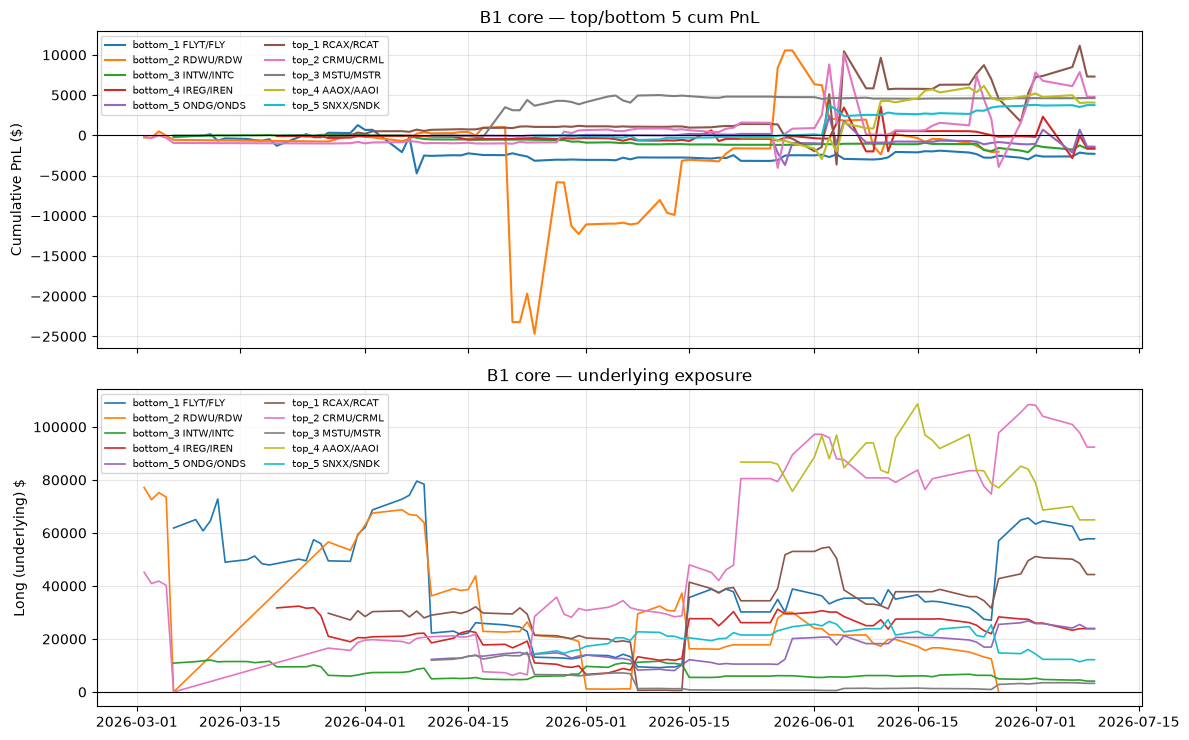


=== B1 core — end-of-sample pair daily ===


,label,date,cum_pnl,underlying_usd,etf_usd,hedge_ratio
13526,top_1 RCAX/RCAT,2026-07-09,"7,296.5400","44,304.3100","-20,036.9300",2.2100
4483,top_2 CRMU/CRML,2026-07-09,"4,775.8600","92,371.4700","-34,776.6000",2.6600
9754,top_3 MSTU/MSTR,2026-07-09,"4,623.8300","3,250.5300","-1,651.5600",1.9700
93,top_4 AAOX/AAOI,2026-07-09,"4,062.0000","64,933.1500","-24,704.0900",2.6300
14681,top_5 SNXX/SNDK,2026-07-09,"3,750.5500","12,183.1800","-4,673.0900",2.6100
11688,bottom_5 ONDG/ONDS,2026-07-09,"-1,413.2700","23,929.1700","-11,691.1000",2.0500
7817,bottom_4 IREG/IREN,2026-07-09,"-1,604.9000","23,883.2400","-11,128.1200",2.1500
7575,bottom_3 INTW/INTC,2026-07-09,"-1,677.4100","4,106.8200","-1,875.9700",2.1900
13680,bottom_2 RDWU/RDW,2026-06-26,"-2,042.4500",0.0000,0.0000,NaN
6282,bottom_1 FLYT/FLY,2026-07-09,"-2,303.9100","57,779.8500","-28,884.1900",2.0000


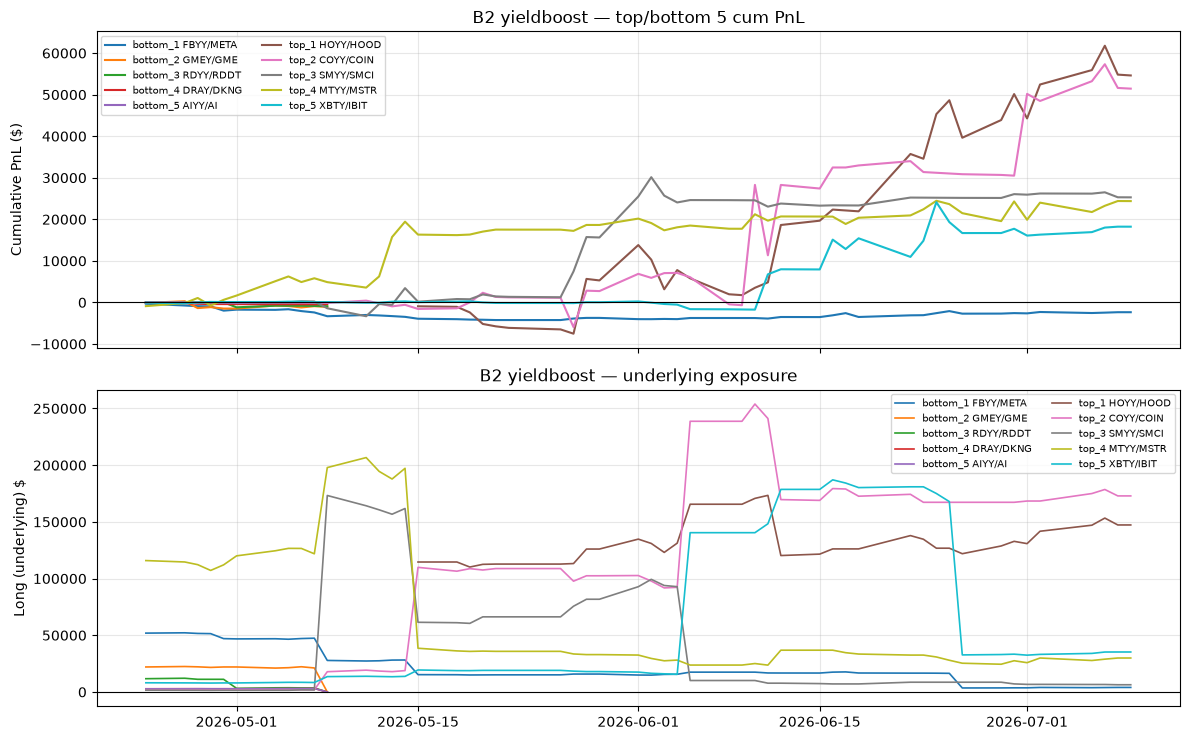


=== B2 yieldboost — end-of-sample pair daily ===


,label,date,cum_pnl,underlying_usd,etf_usd,hedge_ratio
19012,top_1 HOYY/HOOD,2026-07-09,"54,622.0600","147,295.2400","-324,504.9500",0.4500
18849,top_2 COYY/COIN,2026-07-09,"51,450.7300","172,913.0400","-418,432.0000",0.4100
19301,top_3 SMYY/SMCI,2026-07-09,"25,287.9600","6,380.5200","-35,157.7700",0.1800
19168,top_4 MTYY/MSTR,2026-07-09,"24,385.0900","29,964.2300","-94,611.7100",0.3200
19371,top_5 XBTY/IBIT,2026-07-09,"18,229.4900","35,269.6900","-67,236.6600",0.5200
18723,bottom_5 AIYY/AI,2026-05-08,29.6300,0.0000,0.0000,NaN
18860,bottom_4 DRAY/DKNG,2026-05-08,-390.2200,0.0000,0.0000,NaN
19249,bottom_3 RDYY/RDDT,2026-05-08,-906.6100,0.0000,0.0000,NaN
18923,bottom_2 GMEY/GME,2026-05-08,"-1,080.5900",0.0000,0.0000,NaN
18912,bottom_1 FBYY/META,2026-07-09,"-2,355.7200","4,023.2400","-7,178.6900",0.5600


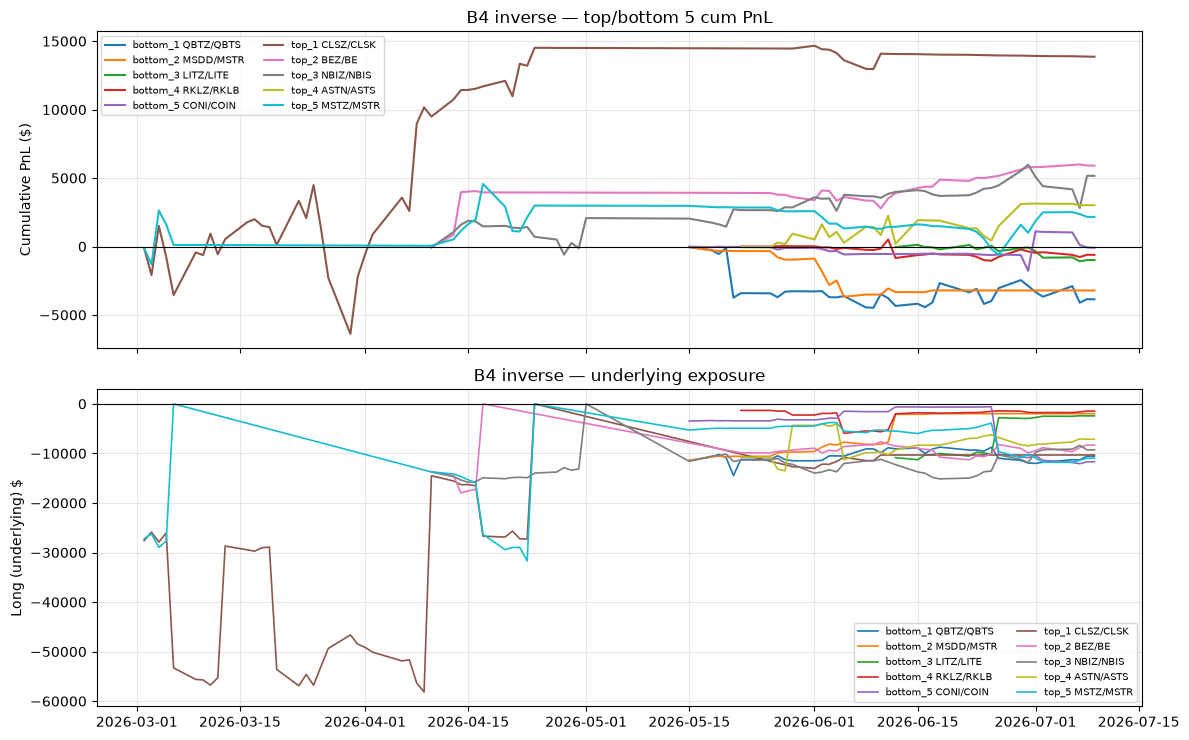


=== B4 inverse — end-of-sample pair daily ===


,label,date,cum_pnl,underlying_usd,etf_usd,hedge_ratio
18300,top_1 CLSZ/CLSK,2026-07-09,"13,862.3400","-10,319.2300","-10,978.5800",0.9400
18233,top_2 BEZ/BE,2026-07-09,"5,906.5800","-8,306.6000","-5,722.2500",1.4500
18587,top_3 NBIZ/NBIS,2026-07-09,"5,158.8400","-9,285.0800","-11,635.1300",0.8000
18195,top_4 ASTN/ASTS,2026-07-09,"3,013.7300","-7,138.8800","-5,301.4700",1.3500
18534,top_5 MSTZ/MSTR,2026-07-09,"2,159.3900","-10,975.3700","-8,954.0700",1.2300
18337,bottom_5 CONI/COIN,2026-07-09,-95.0000,"-11,695.9700","-11,350.4000",1.0300
18656,bottom_4 RKLZ/RKLB,2026-07-09,-610.3600,"-1,459.2400","-1,668.4400",0.8700
18444,bottom_3 LITZ/LITE,2026-07-09,-990.0100,"-2,427.4200","-4,851.1000",0.5000
18481,bottom_2 MSDD/MSTR,2026-07-09,"-3,214.3800","-1,982.1000","-1,502.3500",1.3200
18624,bottom_1 QBTZ/QBTS,2026-07-09,"-3,860.1600","-10,550.9900","-11,865.4900",0.8900


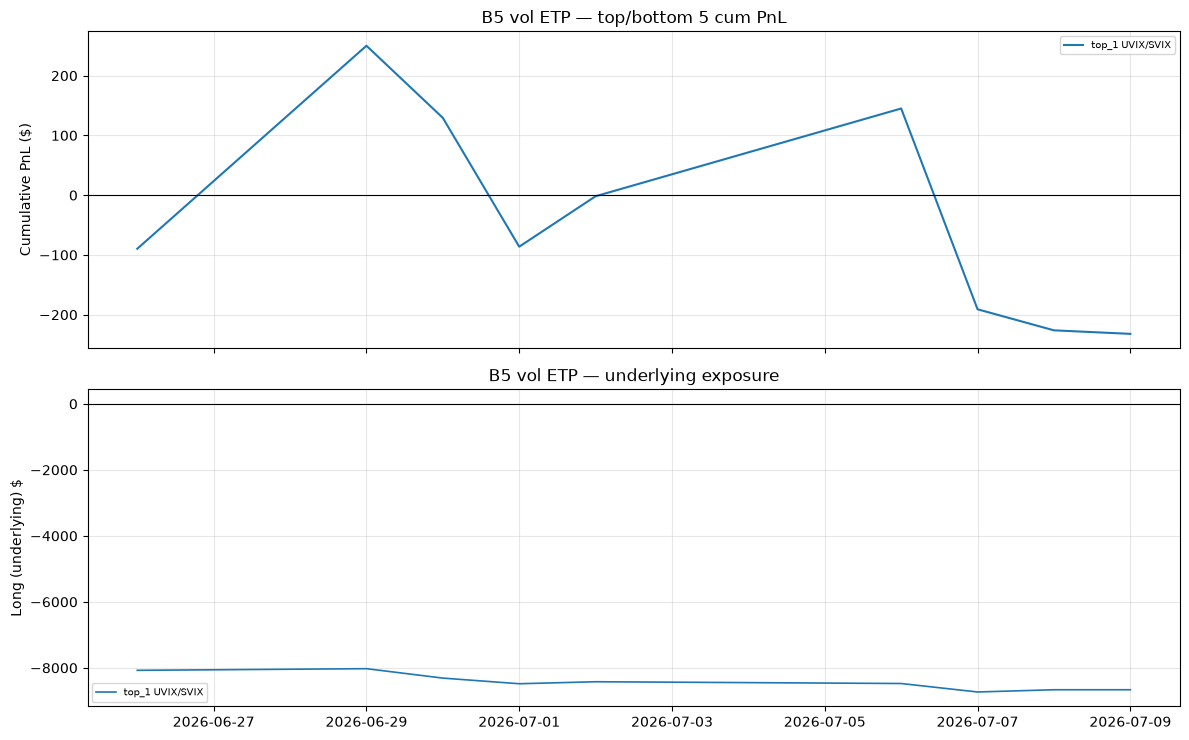


=== B5 vol ETP — end-of-sample pair daily ===


,label,date,cum_pnl,underlying_usd,etf_usd,hedge_ratio
18712,top_1 UVIX/SVIX,2026-07-09,-232.0500,"-8,663.2400","-3,481.5800",2.4900


In [19]:
pdaily_path = OUT_BASE / "pair_daily_pnl.csv"
need = {"long_usd", "short_usd", "hedge_ratio", "rebalance_dates", "pnl_usd"}
if pair_stats_df.empty:
    print("no pair_stats — re-run backtest")
elif not pdaily_path.exists():
    print(
        "no pair_daily_pnl.csv — re-run with FORCE_RERUN=True "
        "(simulator now exports pair×day series)"
    )
elif not need.issubset(pair_stats_df.columns):
    print("pair_stats missing columns for top/bottom selection")
else:
    pdaily = pd.read_csv(pdaily_path, parse_dates=["date"])
    ps = pair_stats_df.copy()
    for sleeve in SLEEVE_ORDER:
        sub = ps[ps["sleeve"].astype(str) == sleeve].sort_values("pnl_usd")
        if sub.empty:
            continue
        bottom = sub.head(5)
        top = sub.tail(5)
        focus = pd.concat([bottom, top], ignore_index=True)
        etfs = set(focus["ETF"].astype(str))
        day = pdaily[
            (pdaily["sleeve"].astype(str) == sleeve)
            & (pdaily["ETF"].astype(str).isin(etfs))
        ].copy()
        if day.empty:
            print(f"{SLEEVE_LABELS.get(sleeve, sleeve)}: no pair_daily rows")
            continue

        rank_map = {}
        for i, r in enumerate(bottom.itertuples(index=False), 1):
            rank_map[str(r.ETF)] = f"bottom_{i} {r.ETF}/{r.Underlying}"
        for i, r in enumerate(top.iloc[::-1].itertuples(index=False), 1):
            rank_map[str(r.ETF)] = f"top_{i} {r.ETF}/{r.Underlying}"

        day["label"] = day["ETF"].astype(str).map(rank_map)
        fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True)

        ax = axes[0]
        for lab, g in day.groupby("label", sort=True):
            g = g.sort_values("date")
            ax.plot(g["date"], g["cum_pnl"], label=lab, lw=1.5)
        ax.axhline(0, color="k", lw=0.8)
        ax.set_ylabel("Cumulative PnL ($)")
        ax.set_title(f"{SLEEVE_LABELS.get(sleeve, sleeve)} — top/bottom 5 cum PnL")
        ax.legend(fontsize=7, ncol=2, loc="best")
        ax.grid(True, alpha=0.3)

        ax = axes[1]
        for lab, g in day.groupby("label", sort=True):
            g = g.sort_values("date")
            ax.plot(g["date"], g["underlying_usd"], label=lab, lw=1.2)
        ax.axhline(0, color="k", lw=0.8)
        ax.set_ylabel("Long (underlying) $")
        ax.set_title(f"{SLEEVE_LABELS.get(sleeve, sleeve)} — underlying exposure")
        ax.legend(fontsize=7, ncol=2, loc="best")
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        end = (
            day.sort_values("date")
            .groupby("label", as_index=False)
            .tail(1)[["label", "date", "cum_pnl", "underlying_usd", "etf_usd", "hedge_ratio"]]
            .sort_values("cum_pnl", ascending=False)
        )
        print(f"\n=== {SLEEVE_LABELS.get(sleeve, sleeve)} — end-of-sample pair daily ===")
        display(end.round(2))


## Why trading starts late (pre-April gap)

Prod mode re-sizes each archived `etf_screened_today.csv` with **today's** GTP.
Pre-2026-04-25 screened files are a thin schema (~27 cols vs ~97): they lack
`net_edge_p50_annual` and most edge/opt2 fields. The backtest shims
`net_edge_p50_annual` from `net_decay_annual`, which is enough for B1/B2 to size.

If `prod_sizing_diag.csv` still shows empty plans until late April, the last run
was before that shim (or hit a transient GTP failure). Re-run with
`FORCE_RERUN=True`. Archived `proposed_trades.csv` also exists sparsely from
2026-03-24 (unused by prod mode) and can seed a hybrid timeline.

### Method to estimate plans from 2026-02-27

1. **Re-run prod** with the edge shim (preferred counterfactual under today's GTP).
2. **Hybrid fill (now default):** where prod sizing still fails, insert that date's
   archived `proposed_trades.csv`; also ingest plan-only dates (no screened CSV).
3. **Schema backfill** (highest fidelity): re-screen Feb–Apr dates so archives
   include full edge bootstrap / B4 opt2 columns, then prod-replay again.
4. **Sanity check**: compare sim pair paths to live
   `data/runs/*/accounting/pnl_bucket_1.csv` for the same underlyings.


## Cumulative sleeve PnL


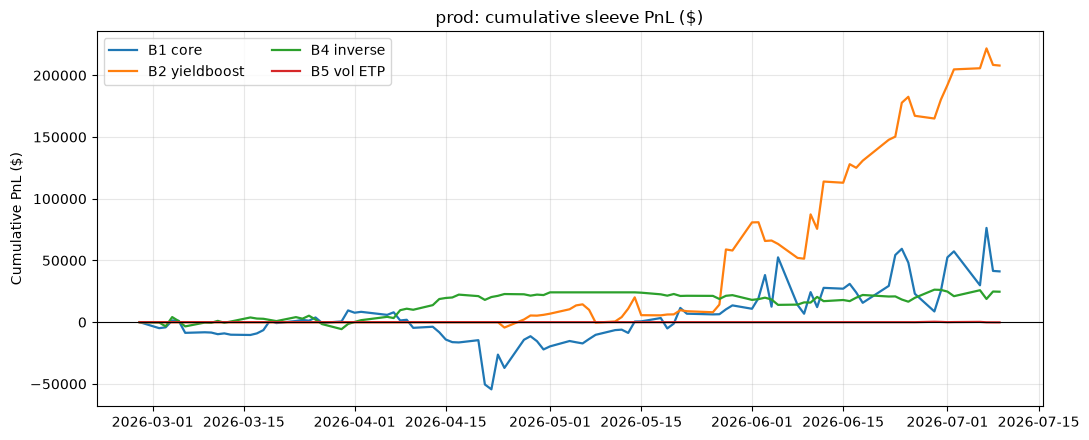

In [20]:
path = OUT_BASE / "sleeve_daily_pnl.csv"
if not path.exists():
    print("no sleeve_daily_pnl.csv")
else:
    sd = pd.read_csv(path, parse_dates=["date"]).set_index("date")
    fig, ax = plt.subplots(figsize=(11, 4.5))
    for s in SLEEVE_ORDER:
        col = f"{s}_cum_pnl"
        if col in sd.columns:
            ax.plot(sd.index, sd[col], label=SLEEVE_LABELS[s], lw=1.6)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title("prod: cumulative sleeve PnL ($)")
    ax.set_ylabel("Cumulative PnL ($)")
    ax.legend(loc="best", ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Prod sizing diagnostics

`prod_sizing_diag.csv` — one row per screened date (ok / fail, n pairs, B4 gross).


prod sizing sources:


source
archived_proposed_fallback    60
prod_replay                   49
Name: count, dtype: int64

,date,source,n_pairs,n_keep_open,gross_sum,gross_b4,n_b4,n_held_in,n_screened,edge_source,n_edge_fallback,ok,error
94,2026-06-26,archived_proposed_fallback,235,107,"2,561,556.3561","107,599.2029",9,9,0,archived_proposed_trades,0,True,plan-only archive (no screened CSV)
95,2026-06-27,archived_proposed_fallback,233,105,"2,482,750.5961","109,108.0378",9,9,0,archived_proposed_trades,0,True,plan-only archive (no screened CSV)
96,2026-06-29,archived_proposed_fallback,237,130,"2,902,045.1212","112,333.5614",10,10,0,archived_proposed_trades,0,True,plan-only archive (no screened CSV)
97,2026-06-30,prod_replay,228,154,"2,316,077.0248","90,741.3995",8,10,540,net_edge_p50_annual,0,True,NaN
98,2026-07-01,prod_replay,250,119,"2,513,753.7683","99,764.9271",10,8,540,net_edge_p50_annual,0,True,NaN
99,2026-07-02,prod_replay,250,115,"2,757,775.7063","91,632.9733",11,10,540,net_edge_p50_annual,0,True,NaN
100,2026-07-03,prod_replay,247,121,"2,765,199.0324","95,580.4635",11,11,540,net_edge_p50_annual,0,True,NaN
101,2026-07-04,prod_replay,246,122,"2,767,028.2086","97,389.3353",11,11,540,net_edge_p50_annual,0,True,NaN
102,2026-07-05,prod_replay,245,122,"2,767,484.3342","97,615.7941",11,11,540,net_edge_p50_annual,0,True,NaN
103,2026-07-06,prod_replay,246,114,"2,507,947.5948","93,898.5159",10,11,540,net_edge_p50_annual,0,True,NaN


B4 gross median=$66,000 max=$1,871,530


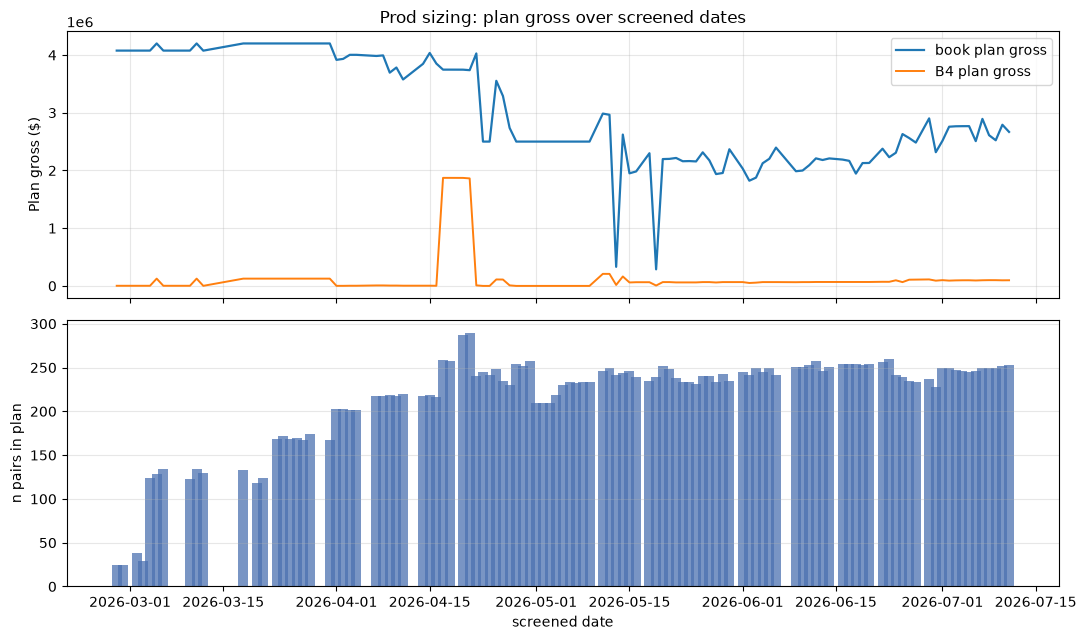

rebalance events: 16


,date,plan_date,n_pairs,turnover_step,turnover_usd,txn_cost_usd,target_planned_gross_usd,target_tradeable_gross_usd,deployed_gross_usd,untradeable_plan_gross_usd,blocked_pairs,n_added,n_exited,n_resize_candidates,n_resized,equity
4,2026-03-27,2026-03-26,168,1.1048,"1,166,613.7868","2,697.6415","2,258,662.0716","2,191,358.0371","2,415,634.7532","67,304.0346",1,38,7,114,91,"1,047,842.8569"
5,2026-04-10,2026-04-09,213,1.7916,"1,904,171.2095","4,286.6256","2,278,447.5195","2,252,715.1300","2,335,954.7006","25,732.3895",0,45,1,156,138,"1,055,456.4067"
6,2026-04-17,2026-04-16,217,0.6657,"701,513.0437","1,568.8717","2,273,518.8956","2,195,048.9184","2,494,182.5091","78,469.9772",0,7,10,183,134,"1,055,881.7774"
7,2026-04-24,2026-04-23,245,3.1404,"3,281,832.0871","7,437.3659","4,030,469.1182","3,872,508.1213","4,116,636.4102","157,960.9969",3,45,25,183,153,"1,031,343.3347"
8,2026-05-01,2026-04-30,251,0.7054,"744,797.5708","1,693.7319","4,124,863.1838","4,066,778.6609","4,033,479.1149","58,084.5229",25,13,4,205,97,"1,061,415.3361"
9,2026-05-08,2026-05-07,244,3.4202,"3,661,265.9683","8,351.0653","4,158,891.1280","4,158,891.1280","4,100,516.4562",0.0000,3,5,24,211,183,"1,063,528.0914"
10,2026-05-15,2026-05-14,260,3.4049,"3,727,546.7479","8,269.8491","4,342,972.7525","4,342,972.7525","4,494,396.2573",0.0000,12,16,16,218,195,"1,080,194.4999"
11,2026-05-22,2026-05-21,265,0.6702,"732,142.3673","1,579.9525","4,343,840.9549","4,343,840.9549","4,580,713.0737",0.0000,124,9,21,191,80,"1,087,101.9911"
12,2026-05-29,2026-05-28,265,0.1129,"128,725.4296",288.7314,"4,563,862.8083","4,563,862.8083","4,870,017.5087",0.0000,146,2,33,179,43,"1,143,536.5338"
13,2026-06-05,2026-06-04,265,1.7594,"2,018,209.2703","4,602.2217","4,726,204.1256","4,726,204.1256","5,076,691.9949",0.0000,90,4,24,193,95,"1,179,910.0905"


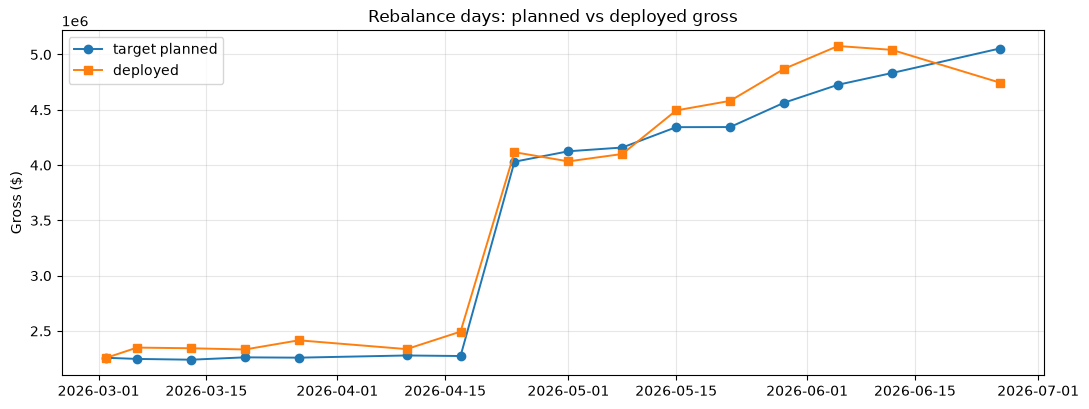

In [21]:
diag_path = OUT_BASE / "prod_sizing_diag.csv"
rebalance_path = OUT_BASE / "rebalance_audit.csv"

if diag_path.exists():
    rd = pd.read_csv(diag_path, parse_dates=["date"])
    print("prod sizing sources:")
    display(rd["source"].value_counts())
    display(rd.tail(15))
    if "gross_b4" in rd.columns and "ok" in rd.columns:
        ok = rd[rd["ok"].astype(bool)]
        if len(ok):
            print(
                f"B4 gross median=${ok['gross_b4'].median():,.0f} "
                f"max=${ok['gross_b4'].max():,.0f}"
            )
            fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
            ax = axes[0]
            ax.plot(ok["date"], ok["gross_sum"], label="book plan gross", lw=1.6)
            ax.plot(ok["date"], ok["gross_b4"], label="B4 plan gross", lw=1.4)
            ax.set_ylabel("Plan gross ($)")
            ax.set_title("Prod sizing: plan gross over screened dates")
            ax.legend(loc="best")
            ax.grid(True, alpha=0.3)
            ax = axes[1]
            ax.bar(ok["date"], ok["n_pairs"], width=1.5, color="#4c72b0", alpha=0.75)
            ax.set_ylabel("n pairs in plan")
            ax.set_xlabel("screened date")
            ax.grid(True, axis="y", alpha=0.3)
            plt.tight_layout()
            plt.show()
    if "error" in rd.columns:
        fails = rd[~rd["ok"].astype(bool)] if "ok" in rd.columns else rd[rd["source"].astype(str).str.contains("fail", na=False)]
        if len(fails):
            print("sizing failures (sample):")
            display(fails[["date", "error"]].head(10))
else:
    print("no prod_sizing_diag.csv")

if rebalance_path.exists():
    ra = pd.read_csv(rebalance_path, parse_dates=["date"])
    print("rebalance events:", len(ra))
    display(ra.tail(12))
    if {"deployed_gross_usd", "target_planned_gross_usd"}.issubset(ra.columns):
        fig, ax = plt.subplots(figsize=(11, 4.2))
        ax.plot(ra["date"], ra["target_planned_gross_usd"], label="target planned", marker="o", lw=1.4)
        ax.plot(ra["date"], ra["deployed_gross_usd"], label="deployed", marker="s", lw=1.4)
        ax.set_title("Rebalance days: planned vs deployed gross")
        ax.set_ylabel("Gross ($)")
        ax.legend(loc="best")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


## Limitations


In [22]:
print("### prod")
for line in report.get("limitations", []):
    print("-", line)
if report.get("prod_stats"):
    print("prod_stats:", report["prod_stats"])
print("\nReport:", OUT_BASE / "REPORT.md")


### prod
- Daily targets from full generate_trade_plan on archived etf_screened_today.csv (opt2 → crash → smooth → ratchet) with isolated state carried forward.
- Borrow/edge inputs: screened spot borrow_current + production edge/opt2 path (no avg-borrow overlay).
- Ratchet floors from prior-day sized plan (simulated), not live Flex holdings.
- Does not prefer archived proposed_trades.csv, but falls back to them when prod sizing fails or on plan-only archive dates.
- Archive gap ~Dec 2025 / sparse screened: pre-2026-04-25 archives lack net_edge_p50_annual — prod replay shims from net_decay_annual (backtest-only).
- B5 included only when GTP sizes it; no live locates / execution rejects.
- Plans sized every screened day; book retargets weekly (W-FRI) with the latest plan (share-hold between Fridays — no daily OLS hedge rebuild).
- Phase-2b hysteresis on existing legs (12%/4%/$250); purgatory keep-open holds shares.
- Sleeve legs scaled to YAML sleeve budgets (scale_sleeves_to_budget) th